## Exploratory Data Analysis Overview

This EDA examines the German day-ahead electricity price dataset with a focus on 24-hour-ahead forecasting. It includes:

- data overview and quality checks
- price distribution, negative prices, and price spikes
- price development over time
- hourly, weekly, monthly, and holiday-related patterns
- relationships between price and key drivers such as load, renewable generation, weather, and fuel prices
- residual demand analysis
- negative price conditions
- forecast-versus-actual diagnostics for selected input variables
- selected time-series checks to support the later modelling phase

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("../data/df_final.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

### Dataset overview

In [2]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (62728, 30)
Date range: 2019-01-08 00:00:00 → 2026-03-05 22:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,...,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.00,0.0,0,1,1,5.0000,...,False,68405.50,13001.0,10497.25,3789.00,8675.50,3505.75,33982.00,0.0,54342.75
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.50,0.0,1,1,1,5.1250,...,False,68068.25,13461.0,10096.25,3614.00,8958.50,3552.00,33866.00,0.0,52541.75
2,2019-01-08 02:00:00,7.78,49241.75,4379.00,33473.50,0.0,2,1,1,4.9875,...,False,67413.75,13093.0,9980.50,3599.00,8720.75,3463.75,33839.50,0.0,51658.75
3,2019-01-08 03:00:00,14.33,49512.25,4134.75,33843.25,0.0,3,1,1,4.8625,...,False,68034.50,13258.0,9996.25,3709.75,8878.75,3473.25,34115.75,0.0,52231.75
4,2019-01-08 04:00:00,18.56,50572.75,3871.50,34549.75,0.0,4,1,1,4.8000,...,False,68487.00,13182.0,10178.50,3971.25,8970.75,3129.75,34217.25,0.0,53853.50



Columns:
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load']

Data types:
timestamp               datetime64[ns]
price                          float64
load                           float64
wind_offshore                  float64
wind_onshore                   float64
solar                          float64
hour                             int64
day_of_week                      int64
month                            int64
temperature                    float64
wind_speed                     float64
is_weekend                        bool
gas_price                      float64
c

### Missing values and duplicates

In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Missing values per column:
timestamp               0
price                   0
load                    0
wind_offshore           0
wind_onshore            0
solar                   0
hour                    0
day_of_week             0
month                   0
temperature             0
wind_speed              0
is_weekend              0
gas_price               0
coal_price              0
price_lag_24h           0
price_lag_168h          0
price_rolling_24h       0
price_rolling_168h      0
co2_price               0
is_holiday              0
is_hol_or_week          0
total_generation        0
net_export              0
coal_generation         0
gas_generation          0
nuclear_generation      0
actual_wind_offshore    0
actual_wind_onshore     0
actual_solar            0
actual_load             0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0


### Time coverage and frequency check

In [4]:
# Show summary statistics of the target variable
print(df["price"].describe().round(2))

# Count how many hours have negative prices
negative_count = (df["price"] < 0).sum()
negative_share = (df["price"] < 0).mean()

# Count how many hours have exactly zero price
zero_count = (df["price"] == 0).sum()

# Count very high price events above 300 €/MWh
high_price_count = (df["price"] > 300).sum()

# Print key target-value indicators
print(f"\nNegative price hours: {negative_count:,} ({negative_share:.2%})")
print(f"Zero price hours: {zero_count:,}")
print(f"Prices above 300 €/MWh: {high_price_count:,}")

count    62728.00
mean        95.12
std         92.90
min       -500.00
25%         38.10
50%         75.90
75%        115.27
max        936.28
Name: price, dtype: float64

Negative price hours: 2,037 (3.25%)
Zero price hours: 189
Prices above 300 €/MWh: 2,655


### Price distribution

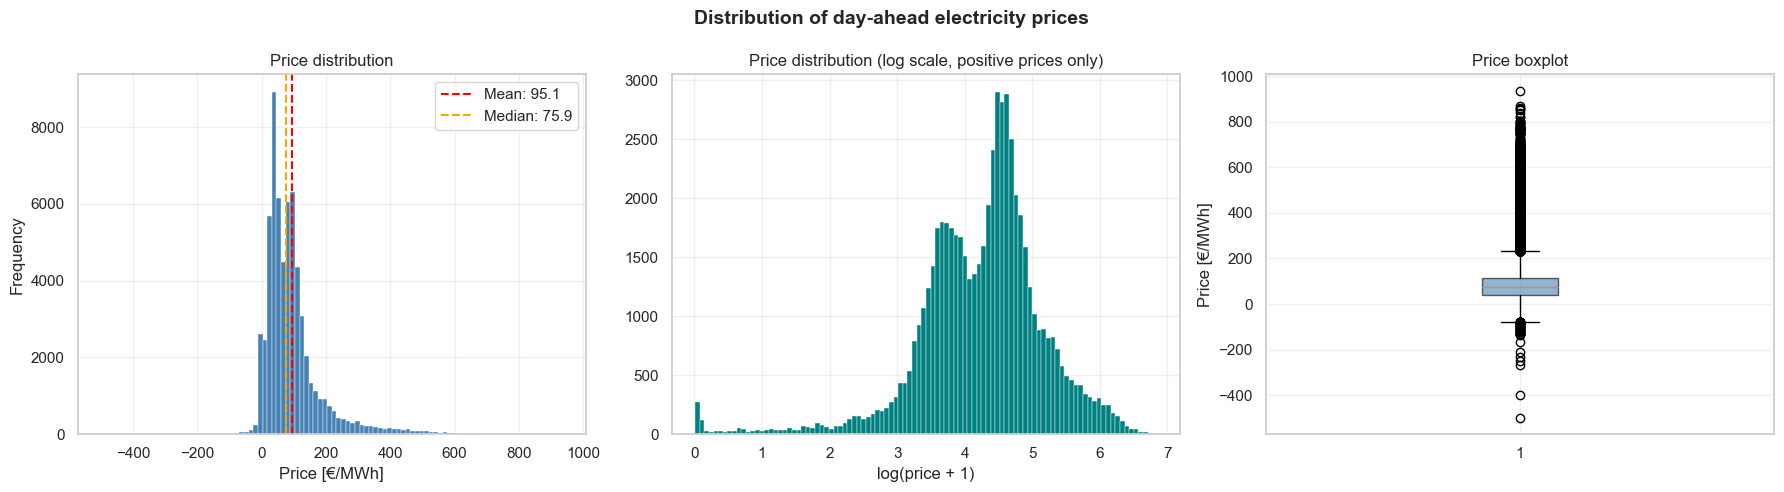

In [5]:
# Create a figure with three plots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: histogram of all price values
axes[0].hist(df["price"], bins=100, color="steelblue", edgecolor="white", linewidth=0.3)

# Add mean and median as vertical reference lines
axes[0].axvline(df["price"].mean(), color="red", linestyle="--", label=f"Mean: {df['price'].mean():.1f}")
axes[0].axvline(df["price"].median(), color="orange", linestyle="--", label=f"Median: {df['price'].median():.1f}")

# Set labels and title for the first plot
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price [€/MWh]")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Plot 2: histogram on log scale for positive prices only
positive_prices = df.loc[df["price"] > 0, "price"]
axes[1].hist(np.log1p(positive_prices), bins=100, color="teal", edgecolor="white", linewidth=0.3)

# Set labels and title for the second plot
axes[1].set_title("Price distribution (log scale, positive prices only)")
axes[1].set_xlabel("log(price + 1)")

# Plot 3: boxplot to show spread and outliers
axes[2].boxplot(
    df["price"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)

# Set labels and title for the third plot
axes[2].set_title("Price boxplot")
axes[2].set_ylabel("Price [€/MWh]")

# Add an overall title and adjust spacing
plt.suptitle("Distribution of day-ahead electricity prices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Price distribution (zoomed view)

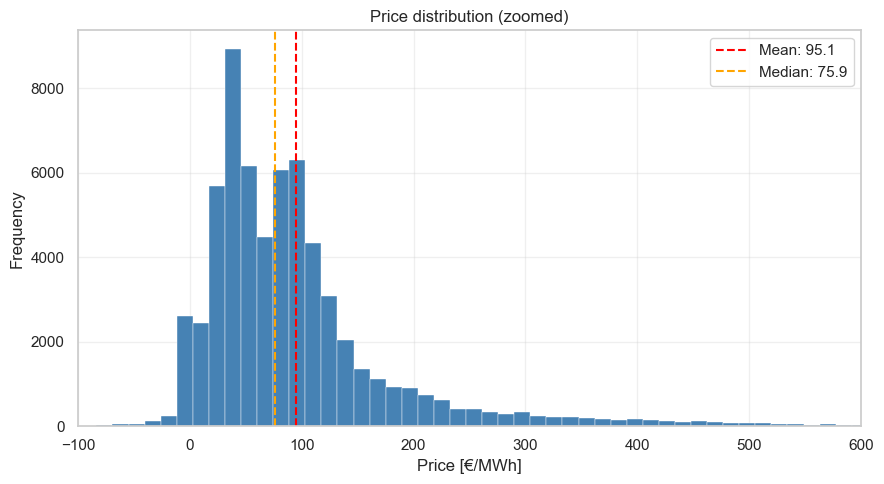

In [6]:
# Create a separate histogram to better inspect the main price range
plt.figure(figsize=(9, 5))

# Plot histogram of all prices
plt.hist(df["price"], bins=100, color="steelblue", edgecolor="white", linewidth=0.3)

# Add mean and median as reference lines
plt.axvline(df["price"].mean(), color="red", linestyle="--", label=f"Mean: {df['price'].mean():.1f}")
plt.axvline(df["price"].median(), color="orange", linestyle="--", label=f"Median: {df['price'].median():.1f}")

# Limit the x-axis so the central part of the distribution is easier to see
plt.xlim(-100, 600)

# Add labels and title
plt.title("Price distribution (zoomed)")
plt.xlabel("Price [€/MWh]")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Price development over time

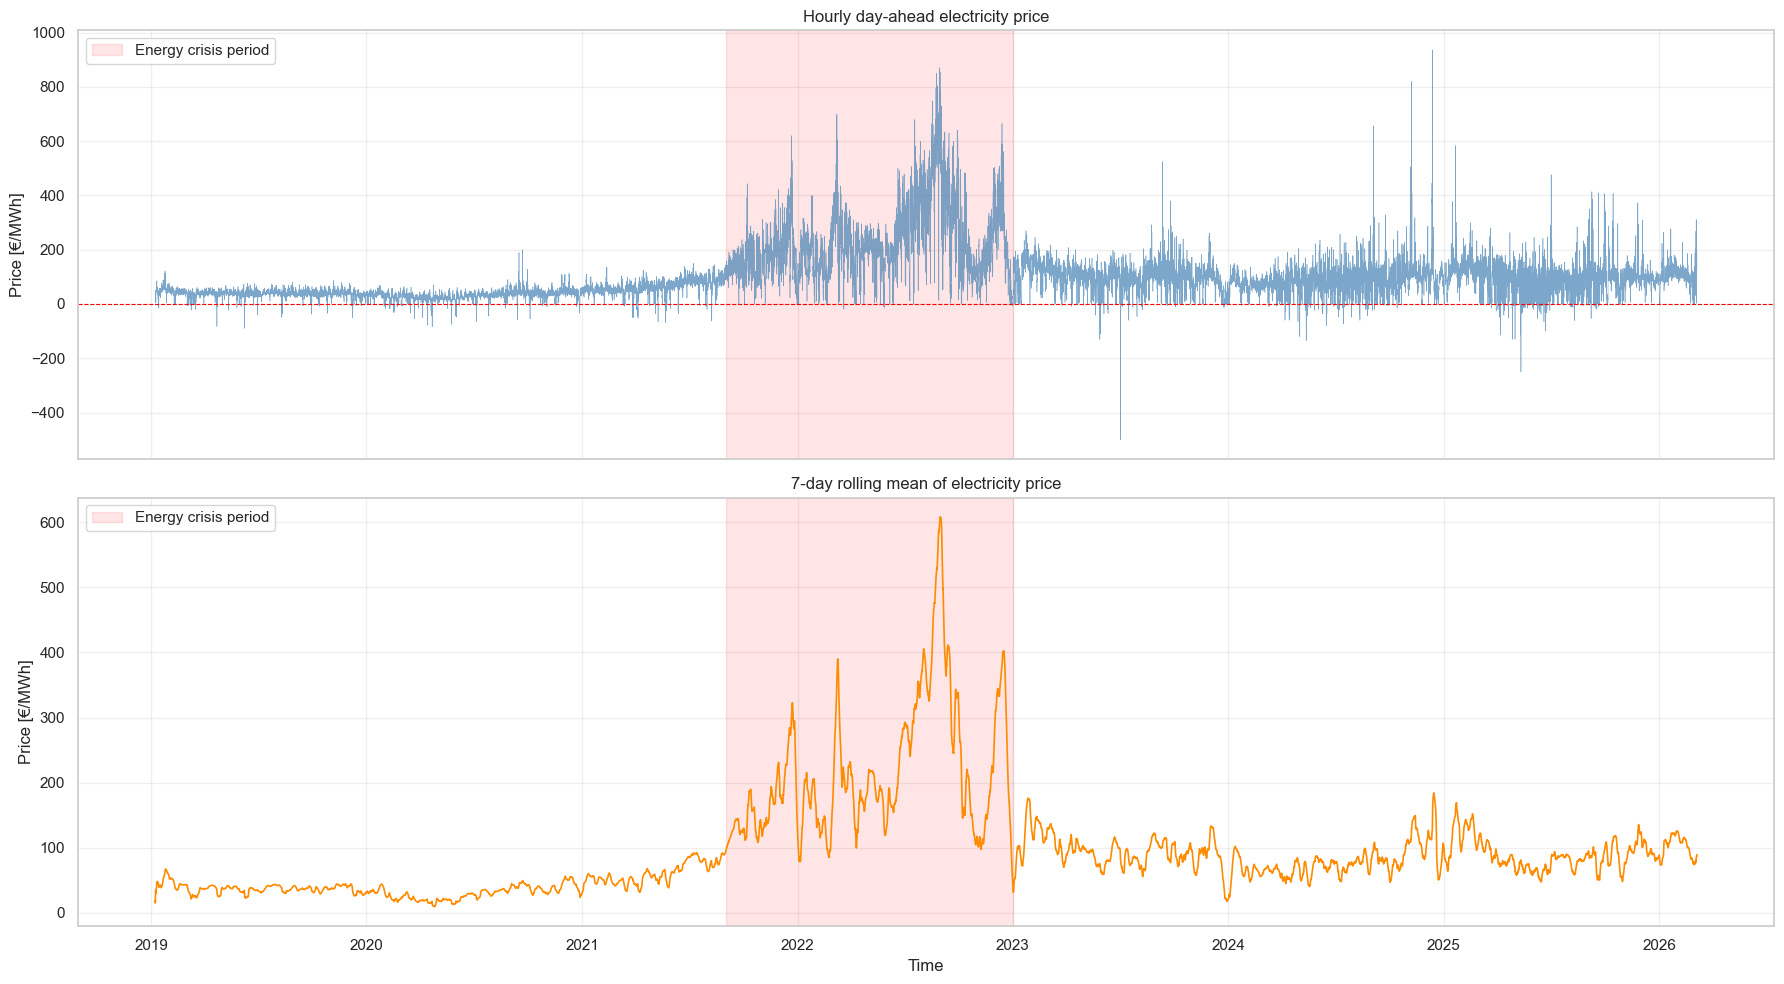

In [7]:
# Create two vertically stacked plots with a shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot 1: full hourly price series
axes[0].plot(df["timestamp"], df["price"], color="steelblue", linewidth=0.4, alpha=0.7)

# Add a horizontal line at zero to highlight negative-price periods
axes[0].axhline(0, color="red", linewidth=0.8, linestyle="--")

# Set labels and title for the first plot
axes[0].set_title("Hourly day-ahead electricity price")
axes[0].set_ylabel("Price [€/MWh]")

# Plot 2: 7-day rolling mean to show the smoother long-term development
rolling_mean_7d = df.set_index("timestamp")["price"].rolling("7D").mean()
axes[1].plot(rolling_mean_7d.index, rolling_mean_7d.values, color="darkorange", linewidth=1.2)

# Set labels and title for the second plot
axes[1].set_title("7-day rolling mean of electricity price")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].set_xlabel("Time")

# Highlight the main energy-crisis period
for ax in axes:
    ax.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-01-01"),
               alpha=0.1, color="red", label="Energy crisis period")
    ax.legend(loc="upper left")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

### Price development over time since 2023

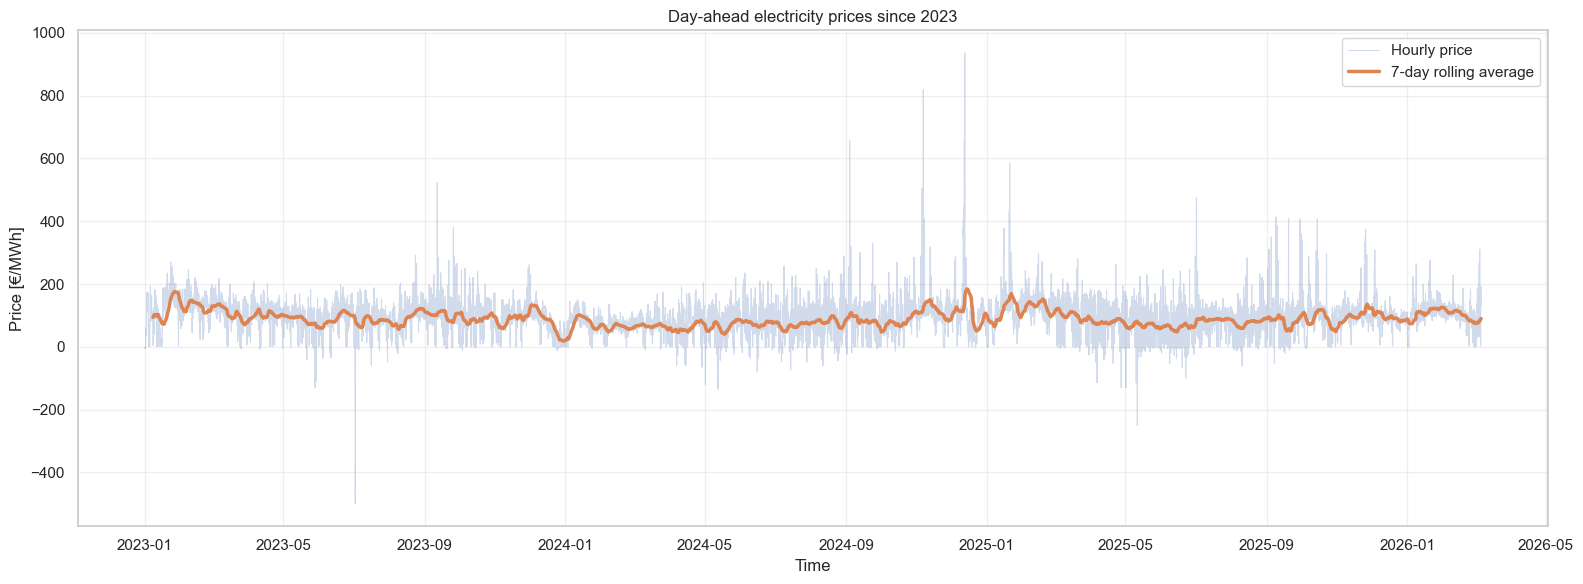

In [8]:
# Filter the dataset to the recent market regime from 2023 onward
df_recent = df[df["timestamp"].dt.year >= 2023].copy()

# Create a 7-day rolling average for the recent period
df_recent["price_rolling_7d"] = df_recent["price"].rolling(24 * 7).mean()

# Plot hourly prices together with the rolling average
plt.figure(figsize=(16, 6))

# Plot the raw hourly price series with low opacity
plt.plot(
    df_recent["timestamp"],
    df_recent["price"],
    alpha=0.25,
    linewidth=0.8,
    label="Hourly price"
)

# Plot the smoother 7-day rolling average
plt.plot(
    df_recent["timestamp"],
    df_recent["price_rolling_7d"],
    linewidth=2.5,
    label="7-day rolling average"
)

# Add labels, title, and legend
plt.title("Day-ahead electricity prices since 2023")
plt.xlabel("Time")
plt.ylabel("Price [€/MWh]")
plt.legend()
plt.tight_layout()
plt.show()

### Price volatility over time

The first plot shows the monthly average price and how strongly prices fluctuate around that average. The second plot shows the full monthly spread from lowest to highest price, so you can see in which periods the market was especially volatile or extreme. The second plot includes both positive and negative prices, because the monthly minimum can be below zero and the monthly maximum can be very high above zero. So it shows the full monthly price range, including negative-price events.

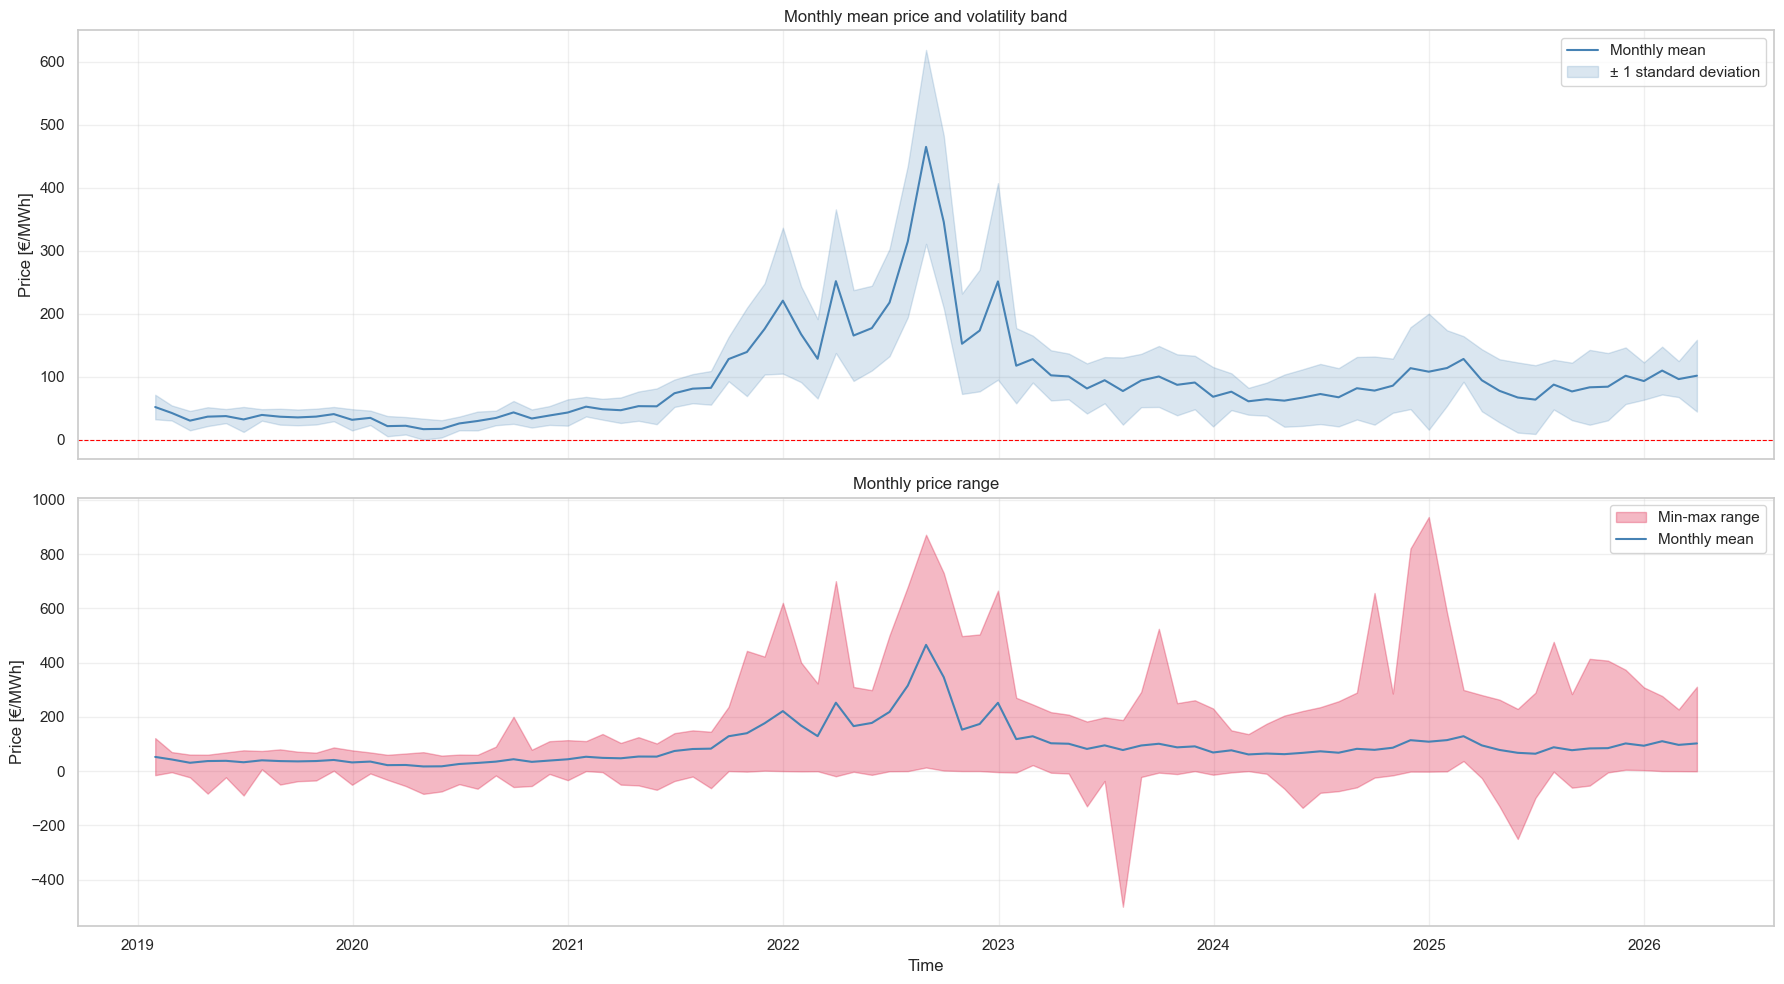

In [9]:
# Aggregate the hourly price series to monthly summary statistics
monthly_price = (
    df.set_index("timestamp")["price"]
      .resample("M")
      .agg(["mean", "std", "min", "max"])
)

# Create two vertically stacked plots with a shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Plot 1: monthly mean price with a +/- 1 standard deviation band
axes[0].plot(
    monthly_price.index,
    monthly_price["mean"],
    color="steelblue",
    linewidth=1.5,
    label="Monthly mean"
)
axes[0].fill_between(
    monthly_price.index,
    monthly_price["mean"] - monthly_price["std"],
    monthly_price["mean"] + monthly_price["std"],
    alpha=0.2,
    color="steelblue",
    label="± 1 standard deviation"
)

# Add a zero-price reference line
axes[0].axhline(0, color="red", linewidth=0.8, linestyle="--")

# Set labels and title for the first plot
axes[0].set_title("Monthly mean price and volatility band")
axes[0].set_ylabel("Price [€/MWh]")
axes[0].legend()

# Plot 2: monthly min-max range together with the monthly mean
axes[1].fill_between(
    monthly_price.index,
    monthly_price["min"],
    monthly_price["max"],
    alpha=0.3,
    color="crimson",
    label="Min-max range"
)
axes[1].plot(
    monthly_price.index,
    monthly_price["mean"],
    color="steelblue",
    linewidth=1.5,
    label="Monthly mean"
)

# Set labels and title for the second plot
axes[1].set_title("Monthly price range")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].legend()

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()

### Price seasonality by hour, weekday, and month

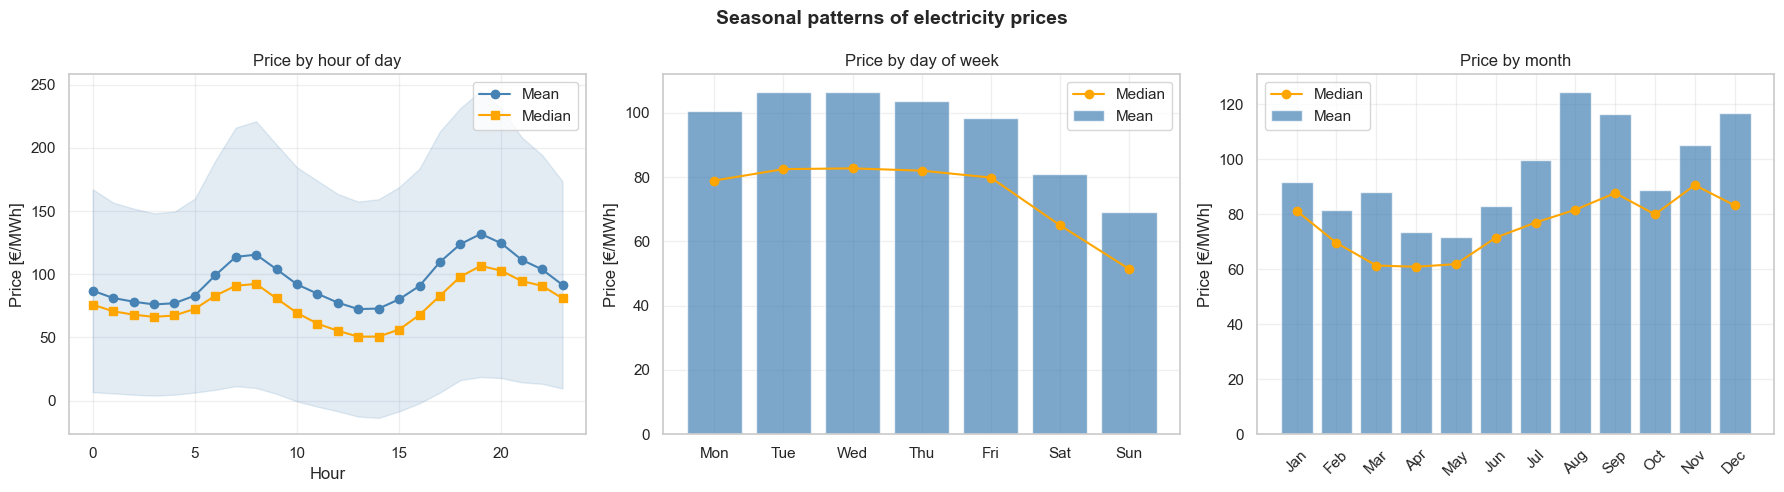

In [10]:
# Create a figure with three plots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Group prices by hour of day and calculate mean, median, and standard deviation
hour_stats = df.groupby("hour")["price"].agg(["mean", "median", "std"])

# Plot average and median price by hour
axes[0].plot(hour_stats.index, hour_stats["mean"], marker="o", color="steelblue", label="Mean")
axes[0].plot(hour_stats.index, hour_stats["median"], marker="s", color="orange", label="Median")

# Add a shaded band for one standard deviation around the mean
axes[0].fill_between(
    hour_stats.index,
    hour_stats["mean"] - hour_stats["std"],
    hour_stats["mean"] + hour_stats["std"],
    alpha=0.15,
    color="steelblue"
)

# Set labels and title for the hourly plot
axes[0].set_title("Price by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Price [€/MWh]")
axes[0].legend()

# Group prices by day of week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_stats = df.groupby("day_of_week")["price"].agg(["mean", "median"])

# Plot average and median price by day of week
axes[1].bar(dow_labels, dow_stats["mean"], color="steelblue", alpha=0.7, label="Mean")
axes[1].plot(dow_labels, dow_stats["median"], marker="o", color="orange", label="Median")

# Set labels and title for the weekday plot
axes[1].set_title("Price by day of week")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].legend()

# Group prices by month
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_stats = df.groupby("month")["price"].agg(["mean", "median"])

# Plot average and median price by month
axes[2].bar(month_labels, month_stats["mean"], color="steelblue", alpha=0.7, label="Mean")
axes[2].plot(month_labels, month_stats["median"], marker="o", color="orange", label="Median")

# Set labels and title for the monthly plot
axes[2].set_title("Price by month")
axes[2].set_ylabel("Price [€/MWh]")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend()

# Add an overall title and adjust spacing
plt.suptitle("Seasonal patterns of electricity prices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Average price by day type

,count,mean,std,min,25%,50%,75%,max
day_type,,,,,,,,
Weekday,43559.0,104.75,97.49,-83.94,43.66,82.06,123.40,936.28
Weekend,17657.0,74.70,78.14,-500.00,27.79,58.04,100.10,704.62
Holiday,1512.0,56.01,62.11,-129.99,11.94,43.18,88.54,466.62


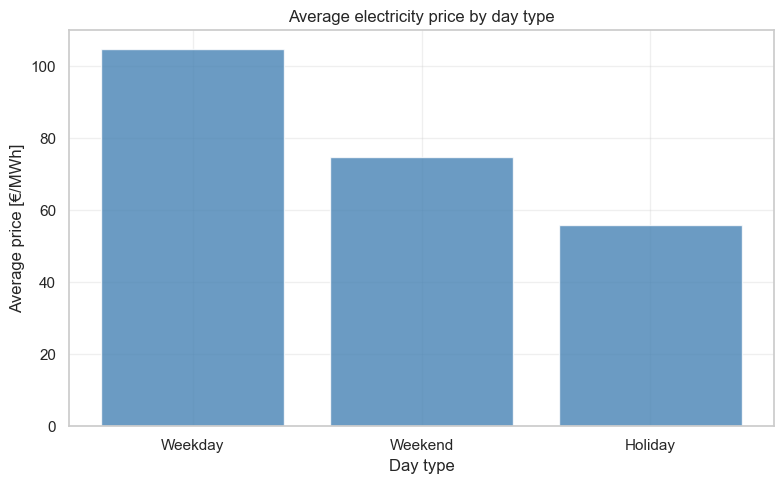

In [11]:
# Create a new column that groups days into weekday, weekend, and holiday
df["day_type"] = "Weekday"
df.loc[df["is_weekend"], "day_type"] = "Weekend"
df.loc[df["is_holiday"], "day_type"] = "Holiday"

# Define the order for display
day_type_order = ["Weekday", "Weekend", "Holiday"]

# Calculate descriptive statistics by day type
day_type_stats = (
    df.groupby("day_type")["price"]
      .describe()
      .reindex(day_type_order)
      .round(2)
)

# Show the summary table
display(day_type_stats)

# Calculate the average price for each day type
avg_price_by_day_type = (
    df.groupby("day_type")["price"]
      .mean()
      .reindex(day_type_order)
)

# Plot the average price by day type
plt.figure(figsize=(8, 5))
plt.bar(avg_price_by_day_type.index, avg_price_by_day_type.values, color="steelblue", alpha=0.8)

# Add labels and title
plt.title("Average electricity price by day type")
plt.xlabel("Day type")
plt.ylabel("Average price [€/MWh]")
plt.tight_layout()
plt.show()

### Average price heatmap by hour and weekday

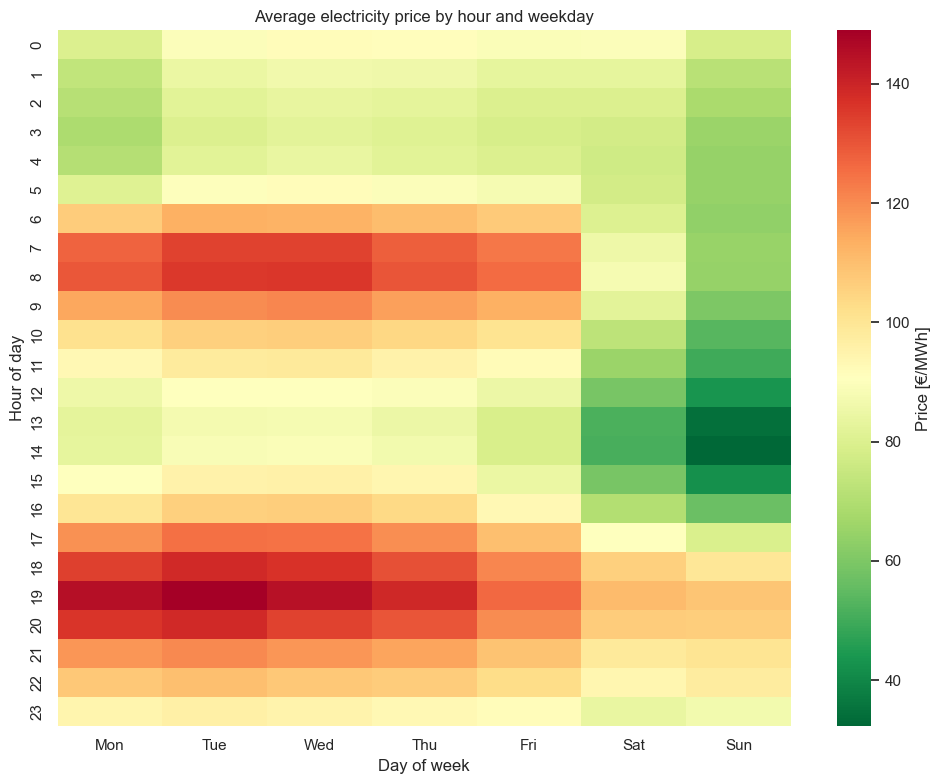

In [12]:
# Create a pivot table with hour of day as rows and day of week as columns
price_heatmap = df.pivot_table(
    values="price",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)

# Rename weekday columns for readability
price_heatmap.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Plot the heatmap of average prices
plt.figure(figsize=(10, 8))
sns.heatmap(
    price_heatmap,
    cmap="RdYlGn_r",
    annot=False,
    cbar_kws={"label": "Price [€/MWh]"}
)

# Add labels and title
plt.title("Average electricity price by hour and weekday")
plt.ylabel("Hour of day")
plt.xlabel("Day of week")
plt.tight_layout()
plt.show()

### Average price heatmap by month and hour

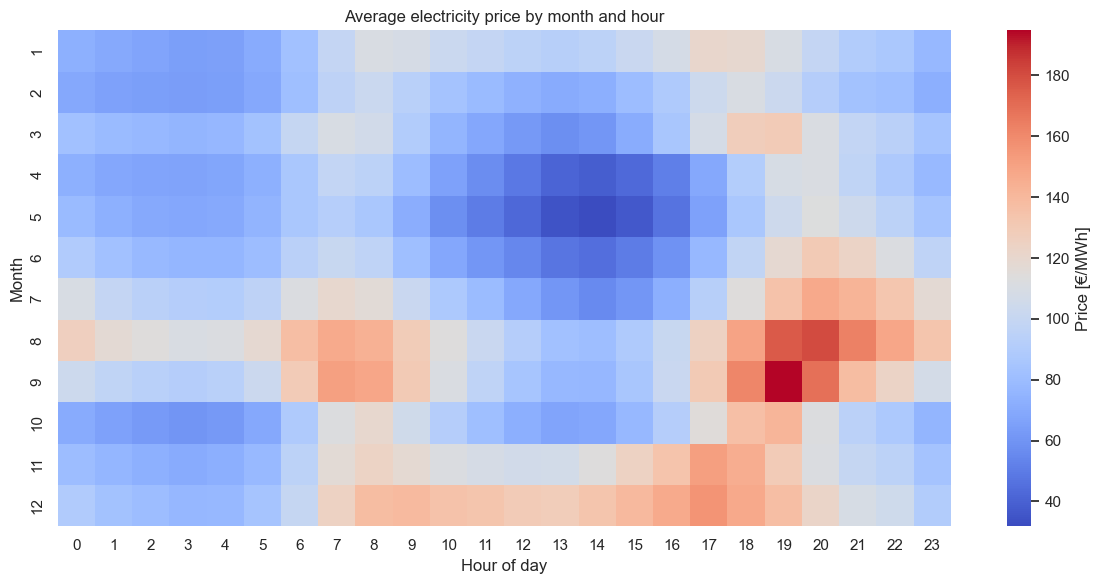

In [13]:
# Create a pivot table with month as rows and hour of day as columns
price_pivot_month_hour = df.pivot_table(
    values="price",
    index="month",
    columns="hour",
    aggfunc="mean"
)

# Plot the heatmap of average prices by month and hour
plt.figure(figsize=(12, 6))
sns.heatmap(
    price_pivot_month_hour,
    cmap="coolwarm",
    annot=False,
    cbar_kws={"label": "Price [€/MWh]"}
)

# Add labels and title
plt.title("Average electricity price by month and hour")
plt.xlabel("Hour of day")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

### Correlation of numerical features with price

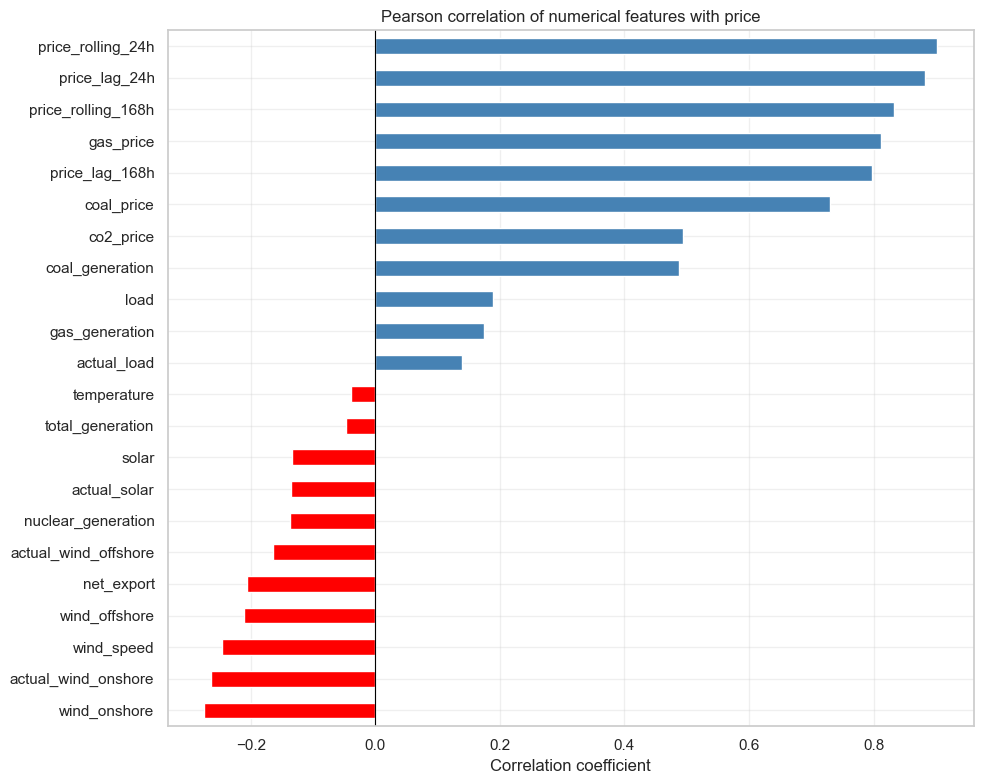

wind_onshore           -0.274
actual_wind_onshore    -0.264
wind_speed             -0.246
wind_offshore          -0.211
net_export             -0.207
actual_wind_offshore   -0.164
nuclear_generation     -0.138
actual_solar           -0.135
solar                  -0.134
total_generation       -0.047
temperature            -0.039
actual_load             0.140
gas_generation          0.175
load                    0.188
coal_generation         0.488
co2_price               0.494
coal_price              0.729
price_lag_168h          0.798
gas_price               0.812
price_rolling_168h      0.833
price_lag_24h           0.882
price_rolling_24h       0.902
Name: price, dtype: float64


In [14]:
# Select all numerical columns from the dataset
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove calendar columns here so the plot focuses on continuous drivers
num_cols = [col for col in num_cols if col not in ["hour", "day_of_week", "month", "year"]]

# Compute Pearson correlation of each numerical feature with price
corr_with_price = (
    df[num_cols]
    .corr()["price"]
    .drop("price")
    .sort_values()
)

# Choose bar colors based on the sign of the correlation
colors = ["red" if value < 0 else "steelblue" for value in corr_with_price]

# Plot correlations as a horizontal bar chart
plt.figure(figsize=(10, 8))
corr_with_price.plot(kind="barh", color=colors)

# Add a vertical reference line at zero
plt.axvline(0, color="black", linewidth=0.8)

# Add labels and title
plt.title("Pearson correlation of numerical features with price")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

# Print the correlation values
print(corr_with_price.round(3))

### Correlation heatmap of selected features

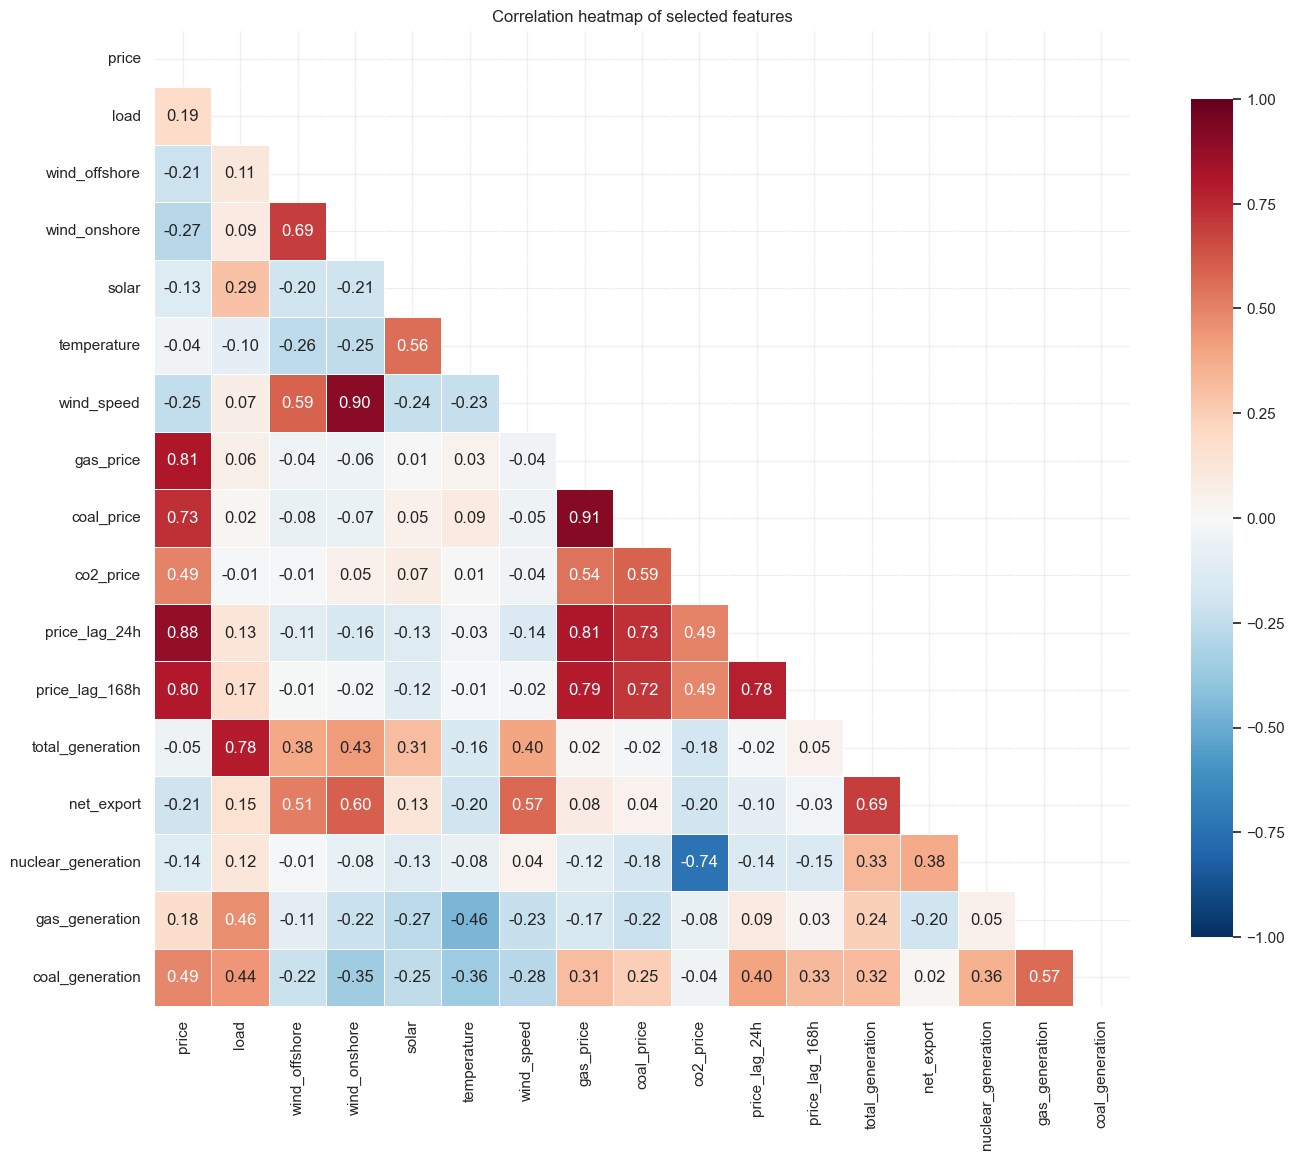

In [15]:
# Select the most relevant features for a compact correlation overview
key_features = [
    "price",
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "temperature",
    "wind_speed",
    "gas_price",
    "coal_price",
    "co2_price",
    "price_lag_24h",
    "price_lag_168h",
    "total_generation",
    "net_export",
    "nuclear_generation",
    "gas_generation",
    "coal_generation"
]

# Keep only columns that actually exist in the dataframe
existing_features = [col for col in key_features if col in df.columns]

# Convert selected columns to numeric where possible
corr_df = df[existing_features].apply(pd.to_numeric, errors="coerce")

# Compute the correlation matrix
corr_matrix = corr_df.corr()

# Create a mask so only one triangle of the symmetric heatmap is shown
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Add title and adjust layout
plt.title("Correlation heatmap of selected features")
plt.tight_layout()
plt.show()

### Residual demand analysis

This plot shows how electricity prices change with residual demand, i.e. the part of demand that remains after wind and solar generation are subtracted. Higher residual demand usually indicates a greater need for conventional generation and is therefore often associated with higher prices.

Correlation between residual demand and price: 0.451


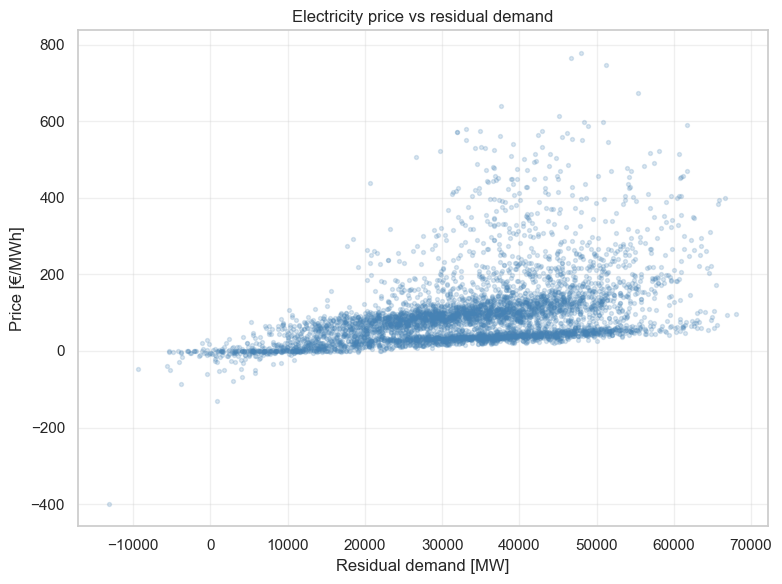

In [16]:
# Create residual demand as load minus renewable generation
df["residual_demand"] = df["load"] - df["wind_offshore"] - df["wind_onshore"] - df["solar"]

# Calculate the correlation between residual demand and price
residual_corr = df["residual_demand"].corr(df["price"])
print(f"Correlation between residual demand and price: {residual_corr:.3f}")

# Create a sample for faster plotting and better readability
sample_residual = df[["residual_demand", "price"]].dropna().sample(
    min(5000, len(df)), random_state=42
)

# Plot price against residual demand
plt.figure(figsize=(8, 6))
plt.scatter(
    sample_residual["residual_demand"],
    sample_residual["price"],
    alpha=0.2,
    s=8,
    color="steelblue"
)

# Add labels and title
plt.title("Electricity price vs residual demand")
plt.xlabel("Residual demand [MW]")
plt.ylabel("Price [€/MWh]")
plt.tight_layout()
plt.show()

### Price vs residual demand (binned)

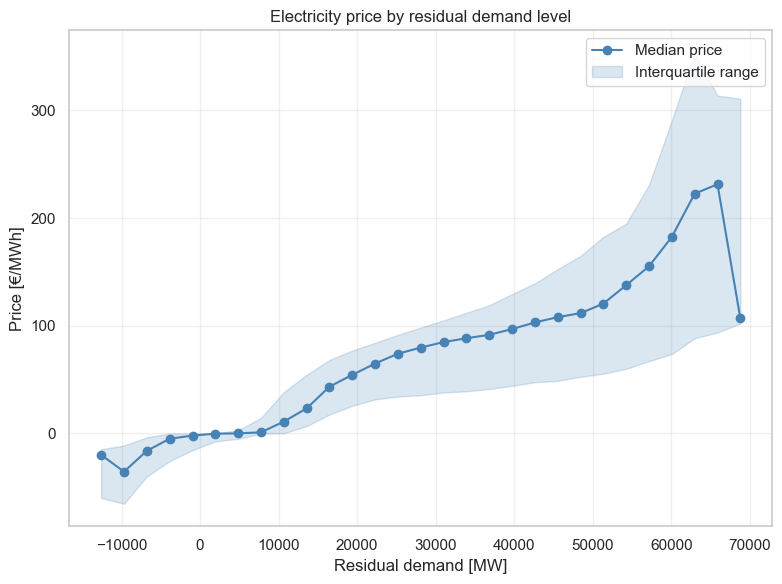

In [17]:
# Create bins for residual demand
bins = np.linspace(df["residual_demand"].min(), df["residual_demand"].max(), 30)
df["residual_demand_bin"] = pd.cut(df["residual_demand"], bins=bins)

# Compute median price and interquartile range for each bin
binned_stats = df.groupby("residual_demand_bin")["price"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reset_index()

# Use bin centers for plotting
bin_centers = [interval.mid for interval in binned_stats["residual_demand_bin"]]

# Plot median price and interquartile range
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, binned_stats["median"], marker="o", color="steelblue", label="Median price")
plt.fill_between(
    bin_centers,
    binned_stats["q25"],
    binned_stats["q75"],
    color="steelblue",
    alpha=0.2,
    label="Interquartile range"
)

# Add labels and title
plt.title("Electricity price by residual demand level")
plt.xlabel("Residual demand [MW]")
plt.ylabel("Price [€/MWh]")
plt.legend()
plt.tight_layout()
plt.show()

### Negative price frequency by hour, month, and year

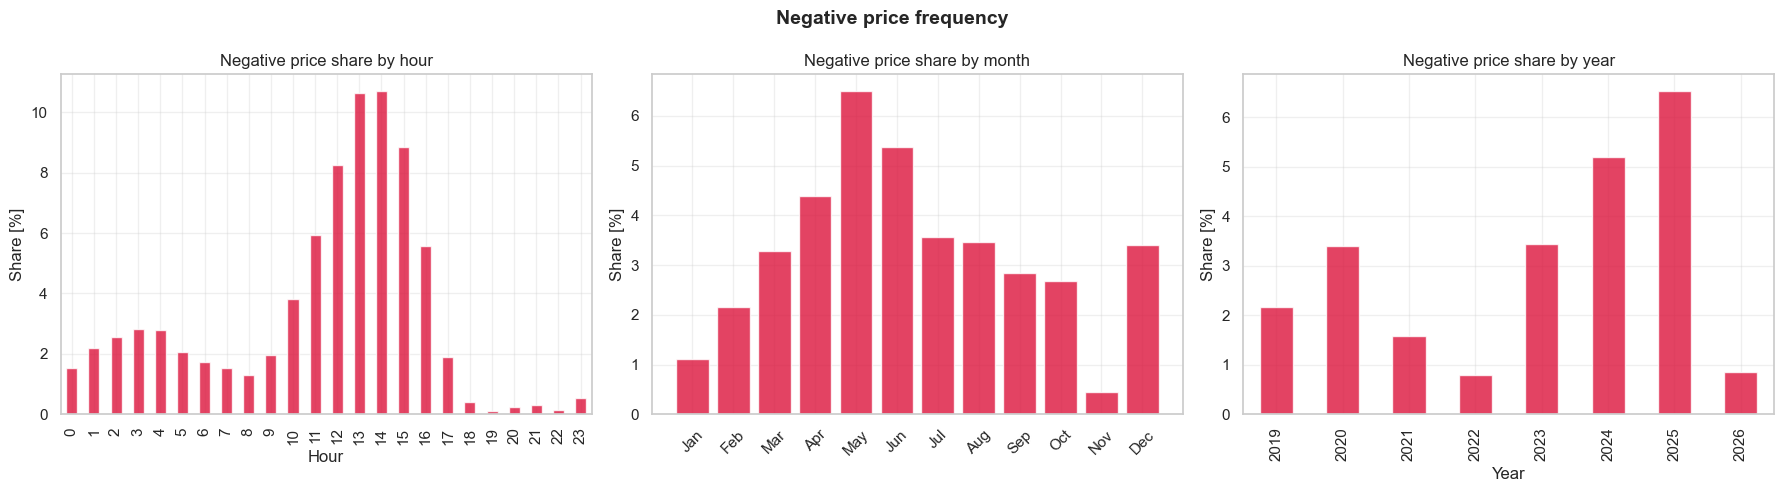

In [18]:
# Create a subset containing only negative price hours
neg = df[df["price"] < 0].copy()

# Add year column if not already present
df["year"] = df["timestamp"].dt.year
neg["year"] = neg["timestamp"].dt.year

# Count the share of negative prices by hour, month, and year
neg_hour = neg.groupby("hour").size()
all_hour = df.groupby("hour").size()

neg_month = neg.groupby("month").size()
all_month = df.groupby("month").size()

neg_year = neg.groupby("year").size()
all_year = df.groupby("year").size()

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot negative price share by hour
(neg_hour / all_hour * 100).plot(kind="bar", ax=axes[0], color="crimson", alpha=0.8)
axes[0].set_title("Negative price share by hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Share [%]")

# Plot negative price share by month
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
neg_month_pct = (neg_month / all_month * 100).reindex(range(1, 13), fill_value=0)
axes[1].bar(month_labels, neg_month_pct.values, color="crimson", alpha=0.8)
axes[1].set_title("Negative price share by month")
axes[1].set_ylabel("Share [%]")
axes[1].tick_params(axis="x", rotation=45)

# Plot negative price share by year
(neg_year / all_year * 100).plot(kind="bar", ax=axes[2], color="crimson", alpha=0.8)
axes[2].set_title("Negative price share by year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Share [%]")

# Adjust layout and show
plt.suptitle("Negative price frequency", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### System conditions during negative and non-negative price hours

,Non-negative price hours,Negative price hours
load,54452.81,49612.52
wind_offshore,2883.57,3416.51
wind_onshore,11626.74,21192.43
solar,5696.51,20556.01
temperature,10.49,16.09
wind_speed,20.64,28.13


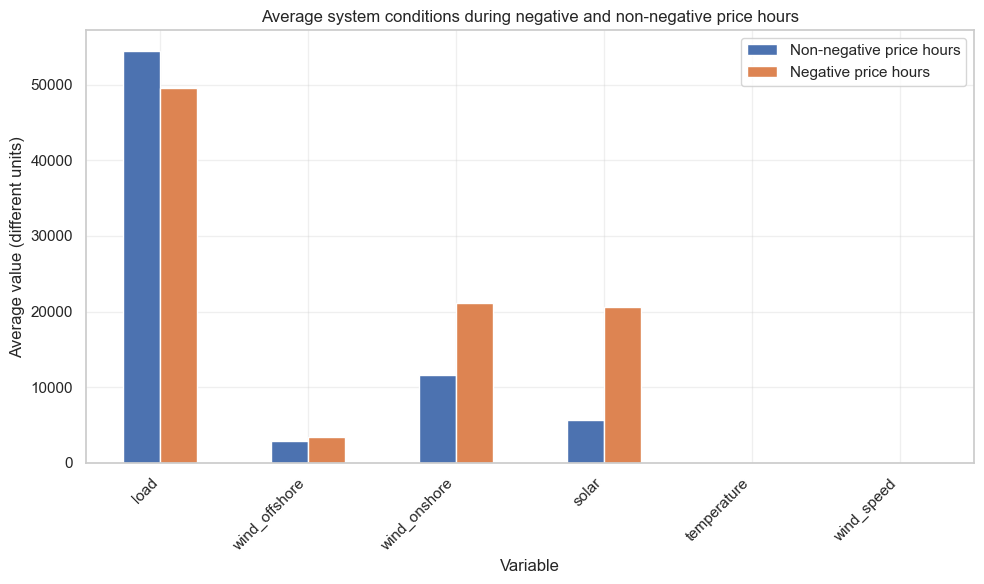

In [19]:
# Create a binary indicator for negative price hours
df["negative_price"] = df["price"] < 0

# Compare average system conditions between negative and non-negative price hours
comparison = df.groupby("negative_price")[[
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "temperature",
    "wind_speed"
]].mean().T

# Rename the columns for clearer legend labels
comparison.columns = ["Non-negative price hours", "Negative price hours"]

# Display the comparison table
display(comparison.round(2))

# Plot the comparison as a bar chart
comparison.plot(kind="bar", figsize=(10, 6))

# Add labels and title
plt.title("Average system conditions during negative and non-negative price hours")
plt.ylabel("Average value (different units)")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
#plt.legend(title="Hour group")
plt.tight_layout()
plt.show()

The colors compare two groups of hours: negative price hours and non-negative price hours. The plot provides a rough comparison of average system conditions, but the variables have different units and should therefore not be compared by absolute bar height across categories.

### Forecast errors of load and renewable generation

Wind offshore   | MAE:   488.78 | RMSE:   692.30 | Bias:    10.37
Wind onshore    | MAE:  1106.73 | RMSE:  1549.02 | Bias:    76.26
Solar           | MAE:   452.12 | RMSE:   949.59 | Bias:    -4.11
Load            | MAE:  2080.83 | RMSE:  2636.64 | Bias:   594.04


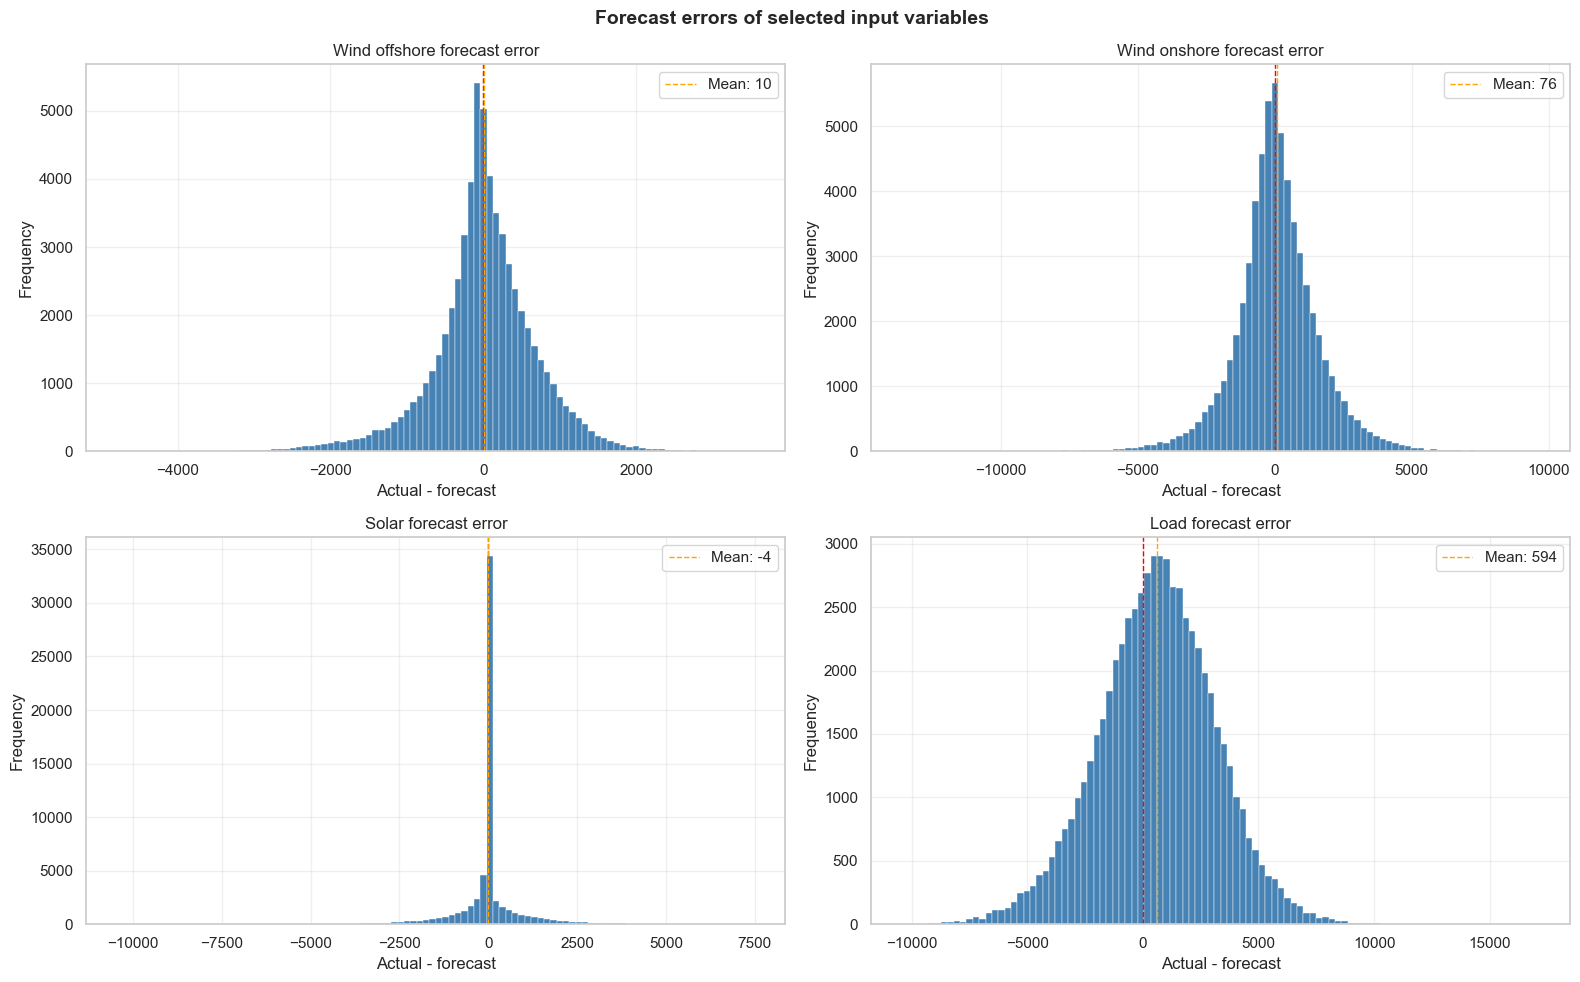

In [20]:
# Calculate forecast errors as actual minus forecast
df["err_wind_offshore"] = df["actual_wind_offshore"] - df["wind_offshore"]
df["err_wind_onshore"] = df["actual_wind_onshore"] - df["wind_onshore"]
df["err_solar"] = df["actual_solar"] - df["solar"]
df["err_load"] = df["actual_load"] - df["load"]

# Store the error series in a dictionary for plotting
errors = {
    "Wind offshore": df["err_wind_offshore"],
    "Wind onshore": df["err_wind_onshore"],
    "Solar": df["err_solar"],
    "Load": df["err_load"]
}

# Create a 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Plot one histogram per forecast error series
for i, (name, err) in enumerate(errors.items()):
    axes[i].hist(err.dropna(), bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].axvline(err.mean(), color="orange", linestyle="--", linewidth=1, label=f"Mean: {err.mean():.0f}")
    axes[i].set_title(f"{name} forecast error")
    axes[i].set_xlabel("Actual - forecast")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

    # Print error metrics for each variable
    mae = err.abs().mean()
    rmse = np.sqrt((err**2).mean())
    bias = err.mean()
    print(f"{name:15s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | Bias: {bias:8.2f}")

# Add overall title and adjust layout
plt.suptitle("Forecast errors of selected input variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

These histograms show how strongly the forecast values deviate from the actual observed values for load and renewable generation. They provide a first impression of forecast accuracy, spread, and possible systematic bias in the input variables used for price forecasting.

### Correlation of forecast errors with price

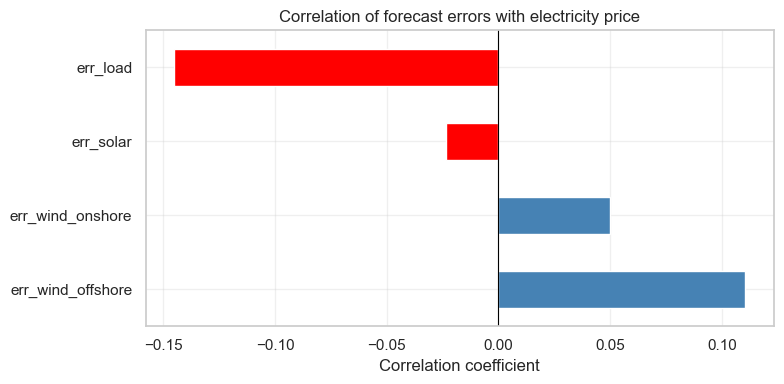

err_wind_offshore    0.1106
err_wind_onshore     0.0499
err_solar           -0.0237
err_load            -0.1452
Name: price, dtype: float64


In [21]:
# Select the forecast error columns
err_cols = ["err_wind_offshore", "err_wind_onshore", "err_solar", "err_load"]

# Compute the Pearson correlation of each forecast error with price
corr_err = df[err_cols + ["price"]].corr()["price"].drop("price")

# Choose colors based on the sign of the correlation
colors = ["red" if value < 0 else "steelblue" for value in corr_err]

# Plot the correlations as a horizontal bar chart
plt.figure(figsize=(8, 4))
corr_err.plot(kind="barh", color=colors)

# Add a vertical reference line at zero
plt.axvline(0, color="black", linewidth=0.8)

# Add labels and title
plt.title("Correlation of forecast errors with electricity price")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

# Print the values
print(corr_err.round(4))

 This figure shows the correlation between forecast errors of selected input variables and electricity price. The relationships are generally weak, but load forecast errors and offshore wind forecast errors show the strongest association with price among the variables considered.

### Key driver relationships with electricity price

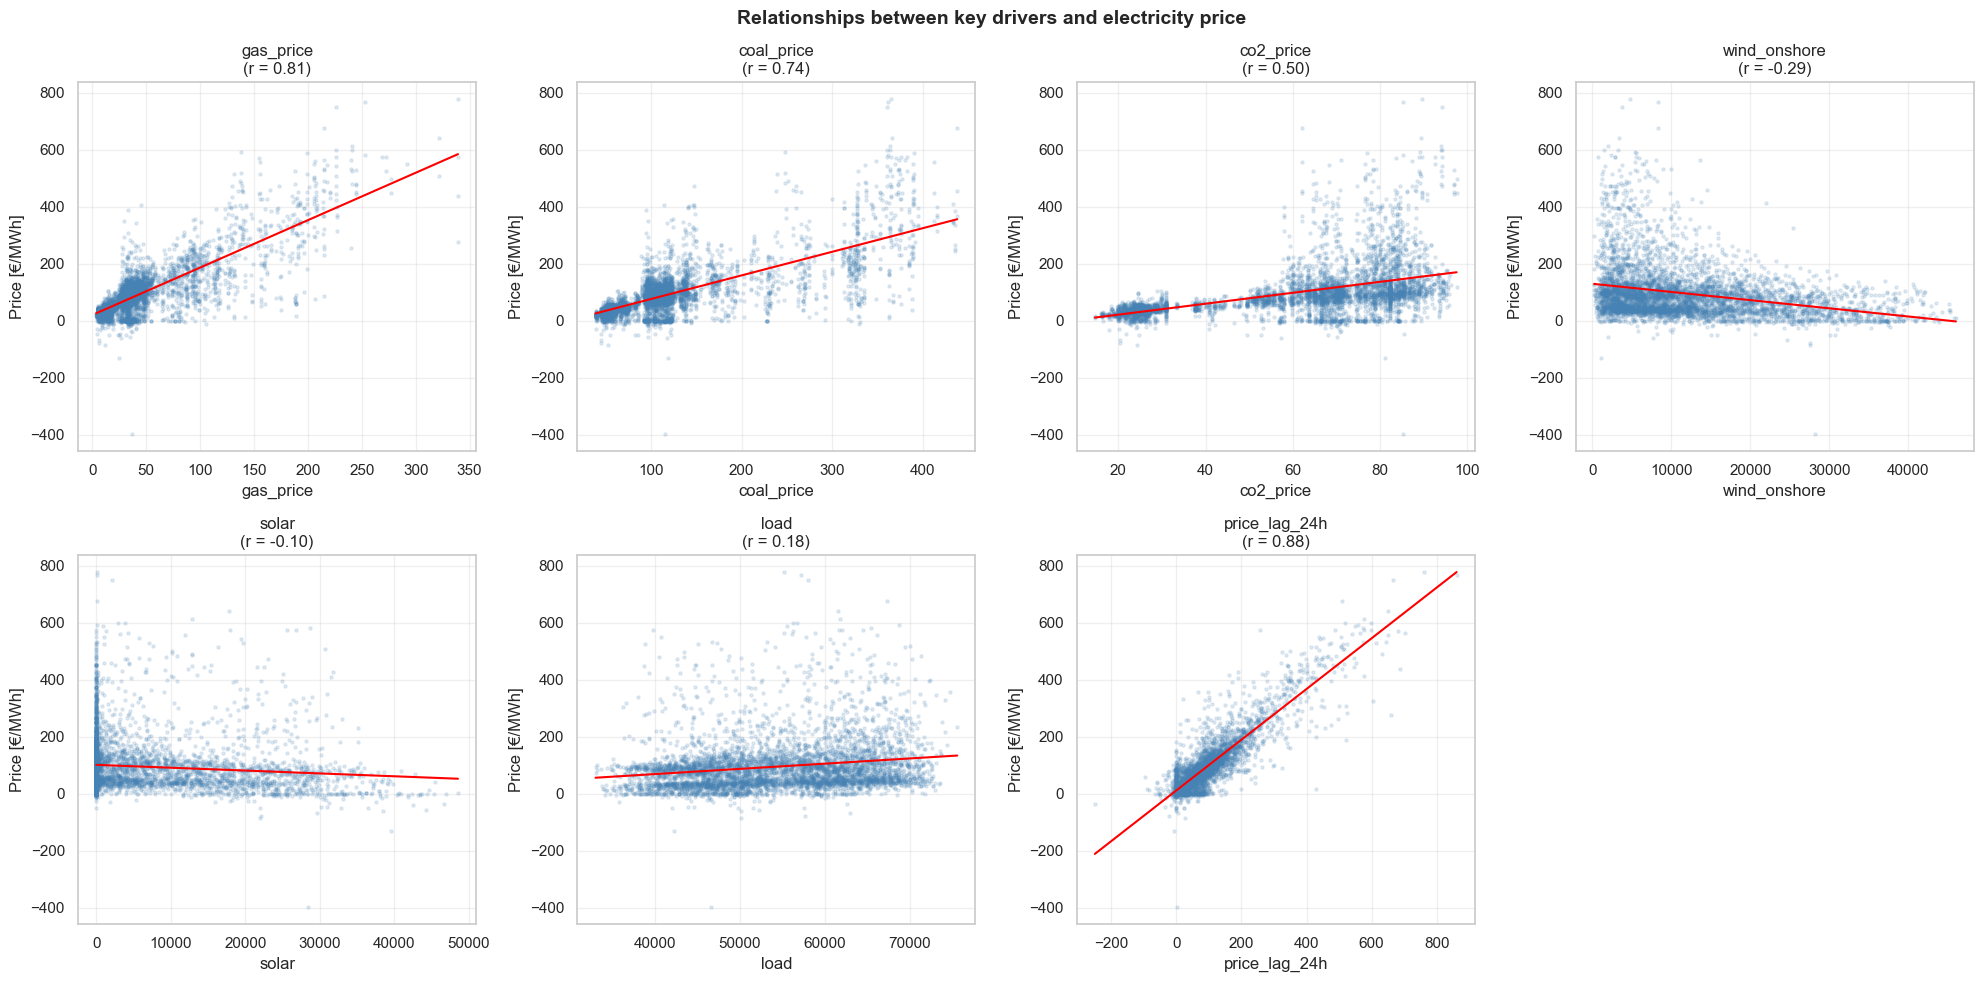

In [22]:
# Select key explanatory variables for scatter plots
key_features_scatter = [
    "gas_price",
    "coal_price",
    "co2_price",
    "wind_onshore",
    "solar",
    "load",
    "price_lag_24h"
]

# Draw a random sample for faster plotting and clearer visualization
sample = df.sample(5000, random_state=42)

# Create a grid of scatter plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Plot each feature against price
for i, feature in enumerate(key_features_scatter):
    axes[i].scatter(
        sample[feature],
        sample["price"],
        alpha=0.15,
        s=5,
        color="steelblue"
    )

    # Fit and plot a simple linear trend line
    valid = sample[[feature, "price"]].dropna()
    z = np.polyfit(valid[feature], valid["price"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[feature].min(), valid[feature].max(), 100)
    axes[i].plot(x_line, p(x_line), color="red", linewidth=1.5)

    # Add labels and correlation value
    corr = valid[feature].corr(valid["price"])
    axes[i].set_title(f"{feature}\n(r = {corr:.2f})")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price [€/MWh]")

# Hide the unused last subplot
axes[-1].axis("off")

# Add overall title and adjust layout
plt.suptitle("Relationships between key drivers and electricity price", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Fuel and carbon price development over time

C:\Users\atefe\AppData\Local\Temp\ipykernel_35648\3570416896.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


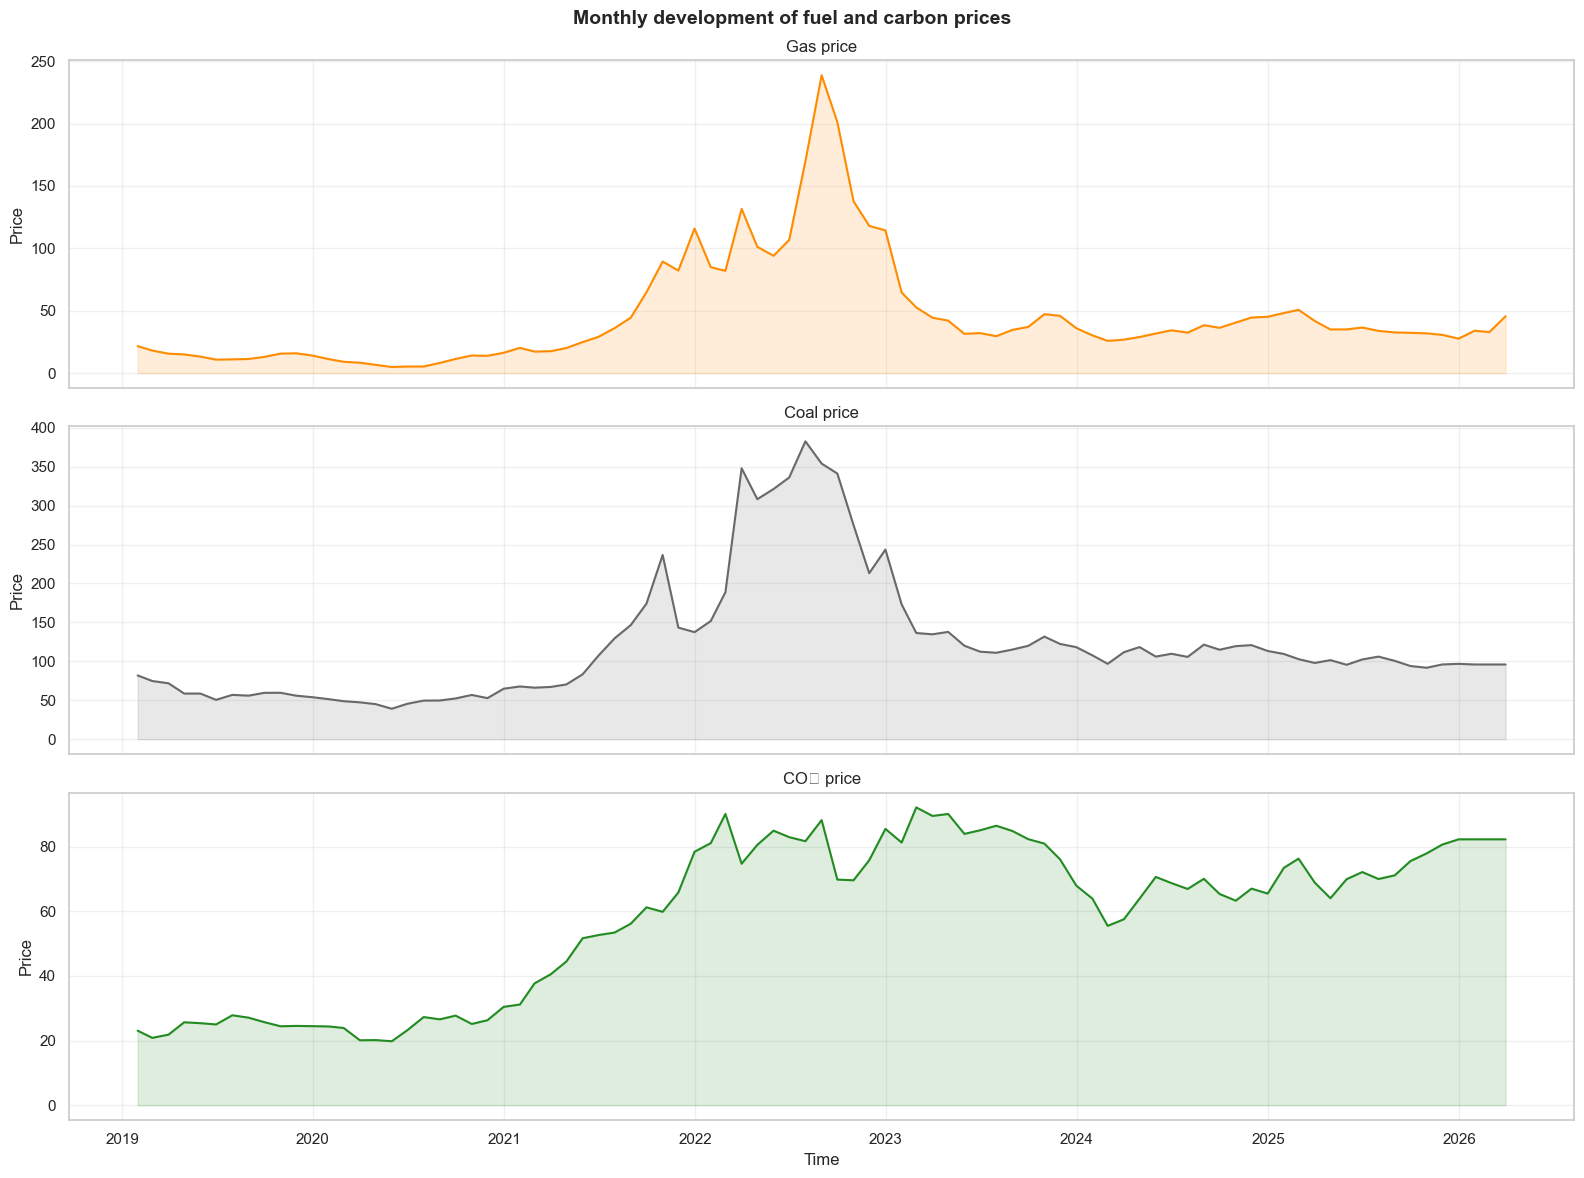

In [23]:
# Aggregate fuel and carbon prices to monthly averages
fuel_monthly = (
    df.set_index("timestamp")[["gas_price", "coal_price", "co2_price"]]
      .resample("M")
      .mean()
)

# Create one subplot per driver
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Define plot labels and colors
fuel_info = [
    ("gas_price", "Gas price", "darkorange"),
    ("coal_price", "Coal price", "dimgray"),
    ("co2_price", "CO₂ price", "forestgreen"),
]

# Plot each monthly time series
for ax, (col, label, color) in zip(axes, fuel_info):
    ax.plot(fuel_monthly.index, fuel_monthly[col], color=color, linewidth=1.5)
    ax.fill_between(fuel_monthly.index, fuel_monthly[col], alpha=0.15, color=color)
    ax.set_title(label)
    ax.set_ylabel("Price")

# Add labels and adjust layout
axes[-1].set_xlabel("Time")
plt.suptitle("Monthly development of fuel and carbon prices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Electricity price and market drivers over time

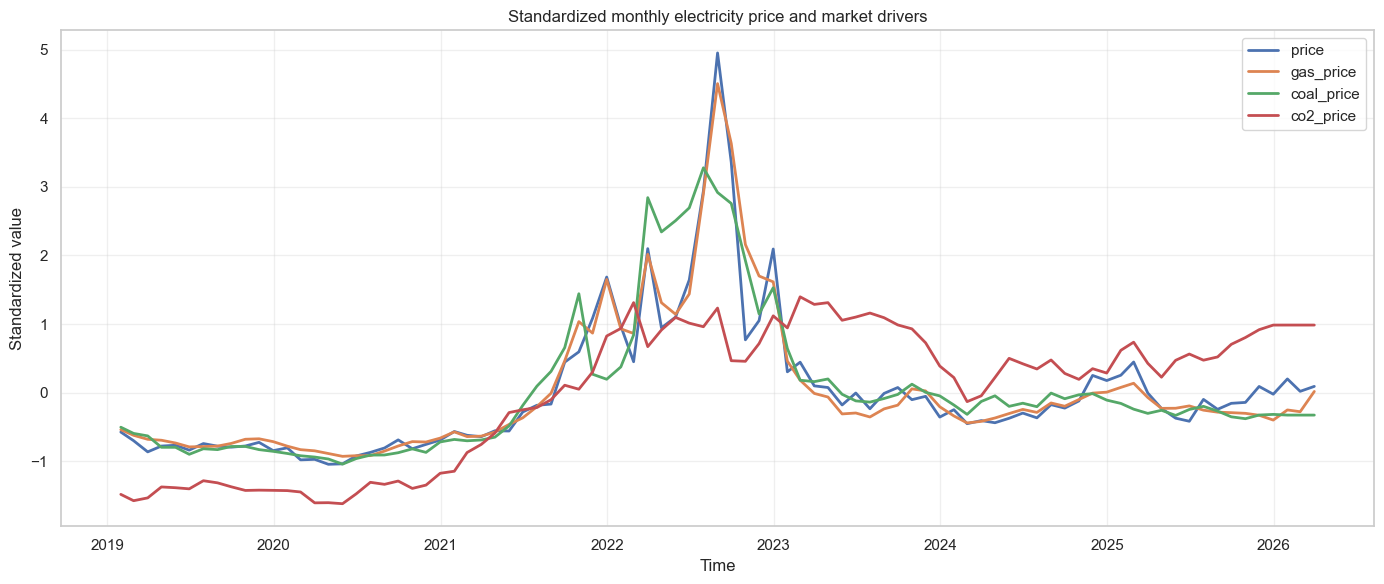

In [24]:
# Aggregate electricity price and market drivers to monthly averages
market_monthly = (
    df.set_index("timestamp")[["price", "gas_price", "coal_price", "co2_price"]]
      .resample("M")
      .mean()
)

# Standardize each series so they can be compared in one plot
market_monthly_scaled = (market_monthly - market_monthly.mean()) / market_monthly.std()

# Plot all standardized series together
plt.figure(figsize=(14, 6))

for col in market_monthly_scaled.columns:
    plt.plot(market_monthly_scaled.index, market_monthly_scaled[col], linewidth=2, label=col)

# Add labels and title
plt.title("Standardized monthly electricity price and market drivers")
plt.xlabel("Time")
plt.ylabel("Standardized value")
plt.legend()
plt.tight_layout()
plt.show()

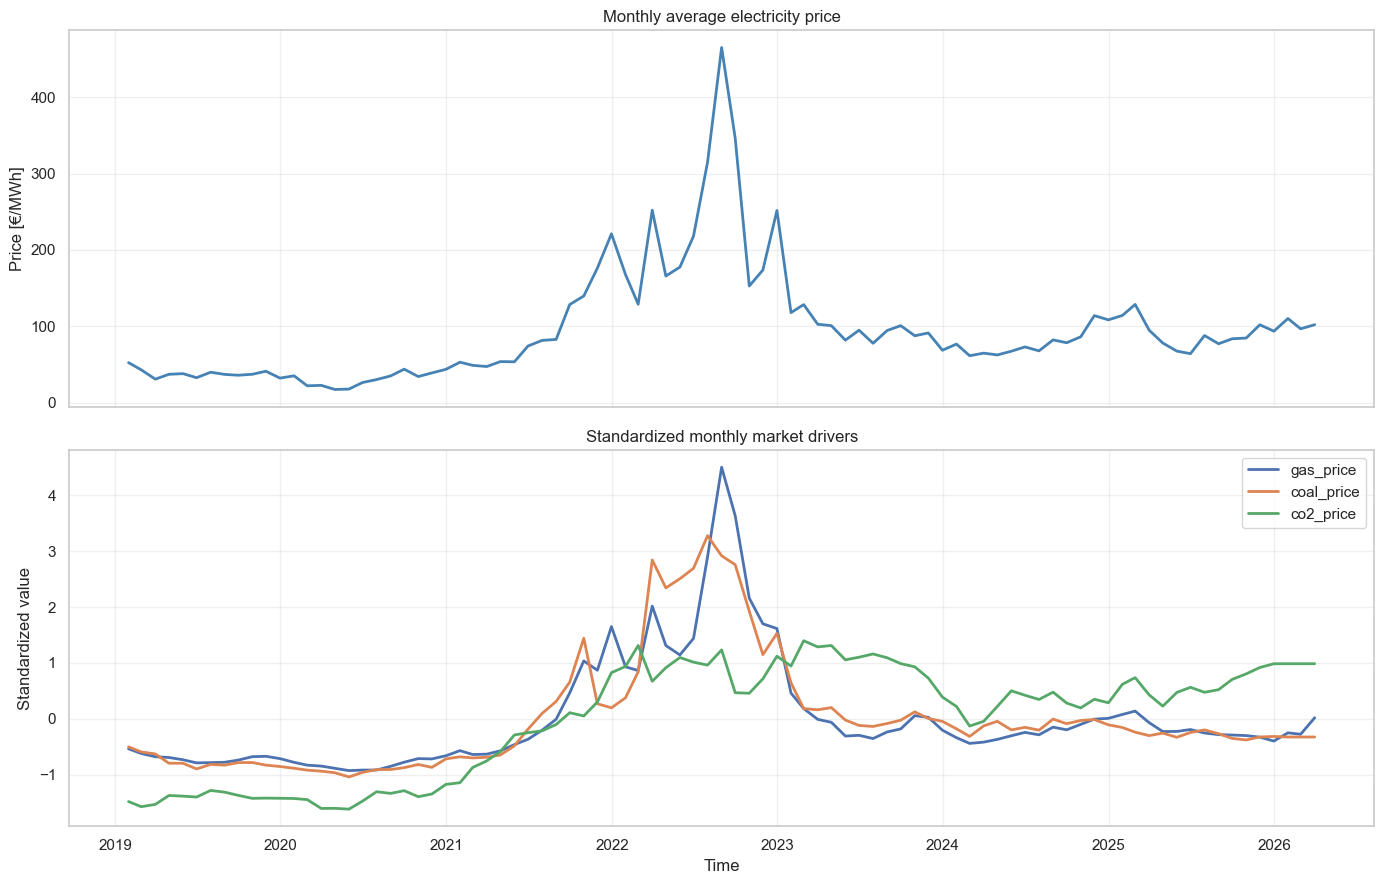

In [25]:
# Aggregate electricity price and market drivers to monthly averages
market_monthly = (
    df.set_index("timestamp")[["price", "gas_price", "coal_price", "co2_price"]]
      .resample("M")
      .mean()
)

# Standardize only the market drivers for easier comparison
drivers_scaled = (
    market_monthly[["gas_price", "coal_price", "co2_price"]] -
    market_monthly[["gas_price", "coal_price", "co2_price"]].mean()
) / market_monthly[["gas_price", "coal_price", "co2_price"]].std()

# Create two stacked plots
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top plot: electricity price in original units
axes[0].plot(
    market_monthly.index,
    market_monthly["price"],
    linewidth=2,
    color="steelblue"
)
axes[0].set_title("Monthly average electricity price")
axes[0].set_ylabel("Price [€/MWh]")

# Bottom plot: standardized market drivers
for col in drivers_scaled.columns:
    axes[1].plot(drivers_scaled.index, drivers_scaled[col], linewidth=2, label=col)

axes[1].set_title("Standardized monthly market drivers")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Standardized value")
axes[1].legend()

plt.tight_layout()
plt.show()

### Recent autocorrelation structure of electricity prices

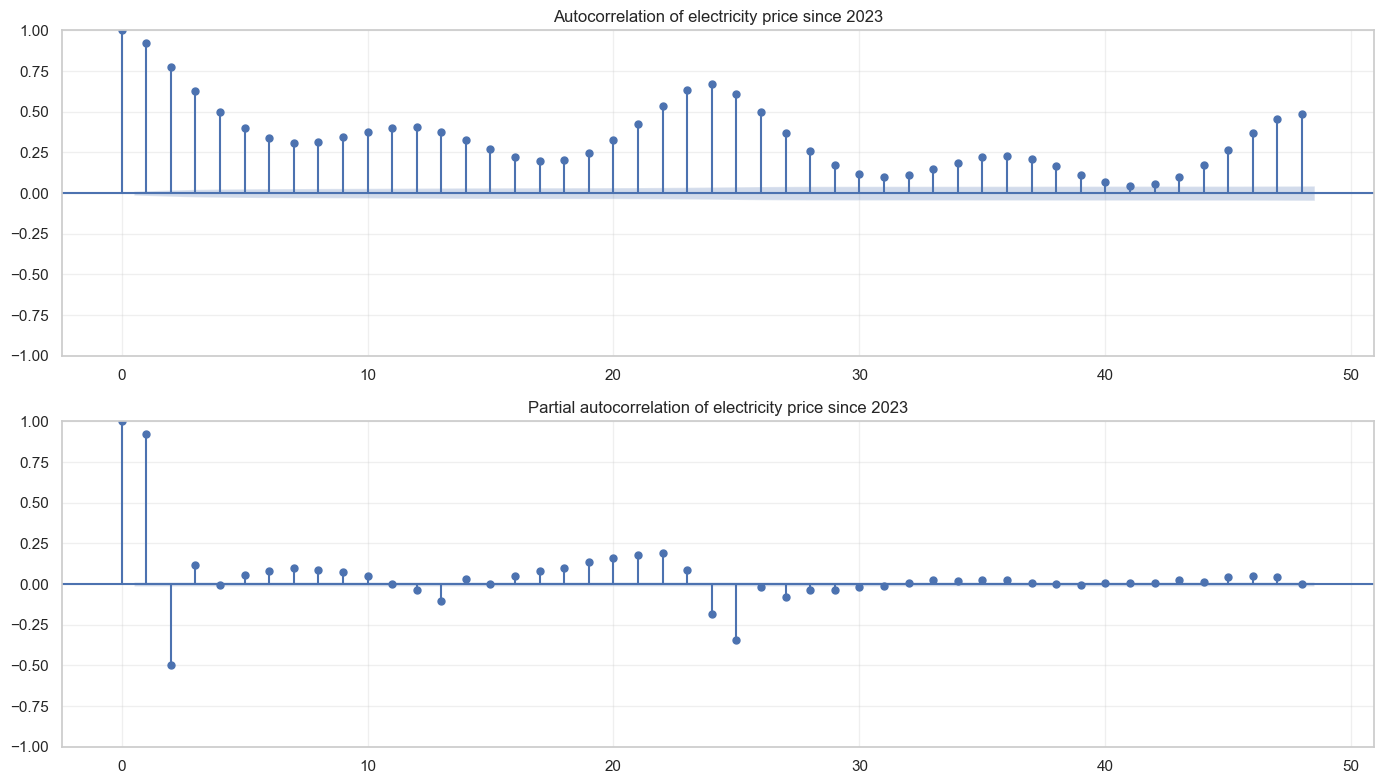

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Select the recent period from 2023 onward
df_recent = df[df["timestamp"].dt.year >= 2023].copy()

# Use the price series without missing values
price_recent = df_recent["price"].dropna()

# Create ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(price_recent, lags=48, ax=axes[0])
axes[0].set_title("Autocorrelation of electricity price since 2023")

plot_pacf(price_recent, lags=48, ax=axes[1], method="ywm")
axes[1].set_title("Partial autocorrelation of electricity price since 2023")

plt.tight_layout()
plt.show()

These plots show how strongly current electricity prices are related to prices in previous hours. They help identify short-term persistence and daily patterns that are relevant for time-series forecasting.

### Stationarity tests of the price series
These tests provide a first indication of whether the electricity price series is stationary or whether its statistical properties change over time. This is useful for assessing how suitable the raw price series is for time-series forecasting methods.

In [27]:
from statsmodels.tsa.stattools import adfuller, kpss

# Use the recent price series from 2023 onward and drop missing values
price_recent = df[df["timestamp"].dt.year >= 2023]["price"].dropna()

# Run Augmented Dickey-Fuller test
adf_result = adfuller(price_recent)

print("ADF test")
print(f"Test statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Lags used: {adf_result[2]}")
print(f"Number of observations: {adf_result[3]}")

# Run KPSS test
kpss_result = kpss(price_recent, regression="c", nlags="auto")

print("\nKPSS test")
print(f"Test statistic: {kpss_result[0]:.4f}")
print(f"p-value: {kpss_result[1]:.6f}")
print(f"Lags used: {kpss_result[2]}")

ADF test
Test statistic: -14.0746
p-value: 0.000000
Lags used: 50
Number of observations: 27785

KPSS test
Test statistic: 0.9941
p-value: 0.010000
Lags used: 81


C:\Users\atefe\AppData\Local\Temp\ipykernel_35648\3834545481.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(price_recent, regression="c", nlags="auto")


These tests provide a first indication of whether the electricity price series is stationary or whether its statistical properties change over time. This is useful for assessing how suitable the raw price series is for time-series forecasting methods.

The ADF test rejects the presence of a unit root, while the KPSS test rejects strict stationarity. Together, these results suggest that the electricity price series has stable short-term dependence but still shows changing level and/or volatility over time, which is typical for power market data.

### Price series after 24-hour differencing

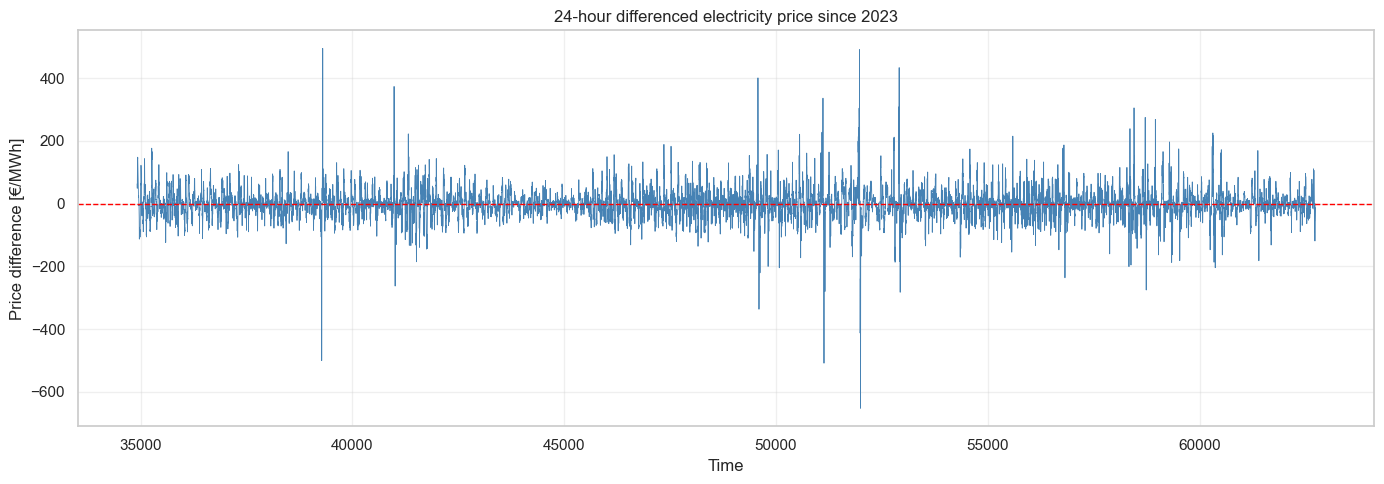

In [28]:
# Create a 24-hour differenced price series for the recent period
price_diff_24h = price_recent.diff(24).dropna()

# Plot the differenced series
plt.figure(figsize=(14, 5))
plt.plot(price_diff_24h.index, price_diff_24h.values, color="steelblue", linewidth=0.6)

# Add a reference line at zero
plt.axhline(0, color="red", linestyle="--", linewidth=1)

# Add labels and title
plt.title("24-hour differenced electricity price since 2023")
plt.xlabel("Time")
plt.ylabel("Price difference [€/MWh]")
plt.tight_layout()
plt.show()

### Price series after 24-hour differencing

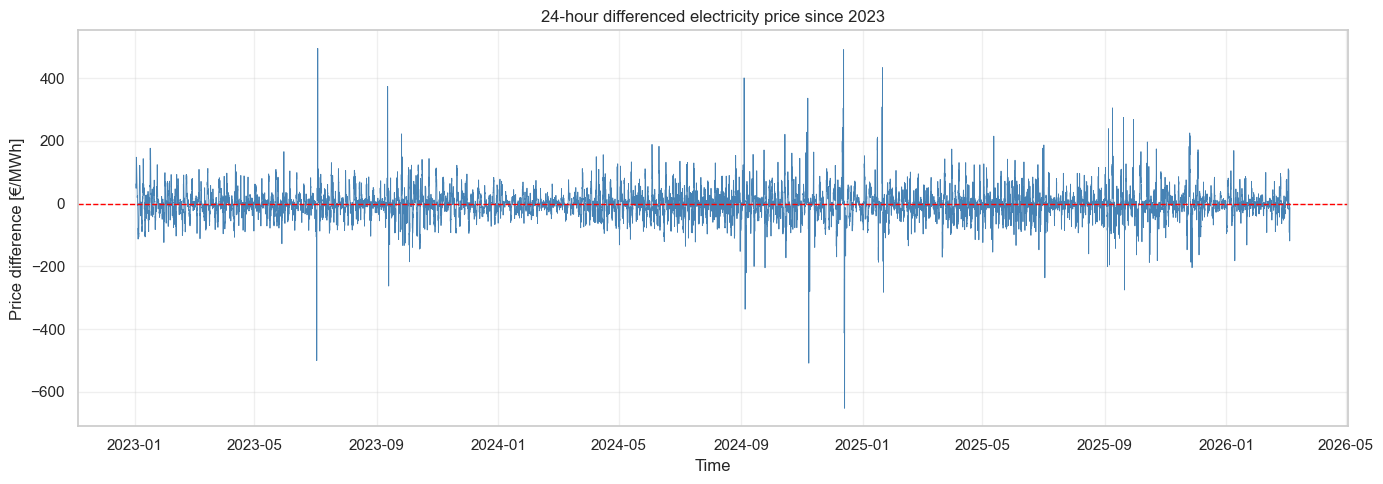

In [29]:
# Select the recent price series from 2023 onward and set timestamp as index
price_recent = (
    df.loc[df["timestamp"].dt.year >= 2023, ["timestamp", "price"]]
      .set_index("timestamp")["price"]
      .dropna()
)

# Compute the 24-hour difference
price_diff_24h = price_recent.diff(24).dropna()

# Plot the differenced series with proper datetime axis
plt.figure(figsize=(14, 5))
plt.plot(price_diff_24h.index, price_diff_24h.values, color="steelblue", linewidth=0.6)

# Add a reference line at zero
plt.axhline(0, color="red", linestyle="--", linewidth=1)

# Add labels and title
plt.title("24-hour differenced electricity price since 2023")
plt.xlabel("Time")
plt.ylabel("Price difference [€/MWh]")
plt.tight_layout()
plt.show()

This plot shows the change in electricity price relative to the same hour on the previous day. Most values remain close to zero, which indicates a strong daily pattern, but the large positive and negative spikes show that substantial day-to-day deviations still occur.

### Forecast vs actual values for selected input variables

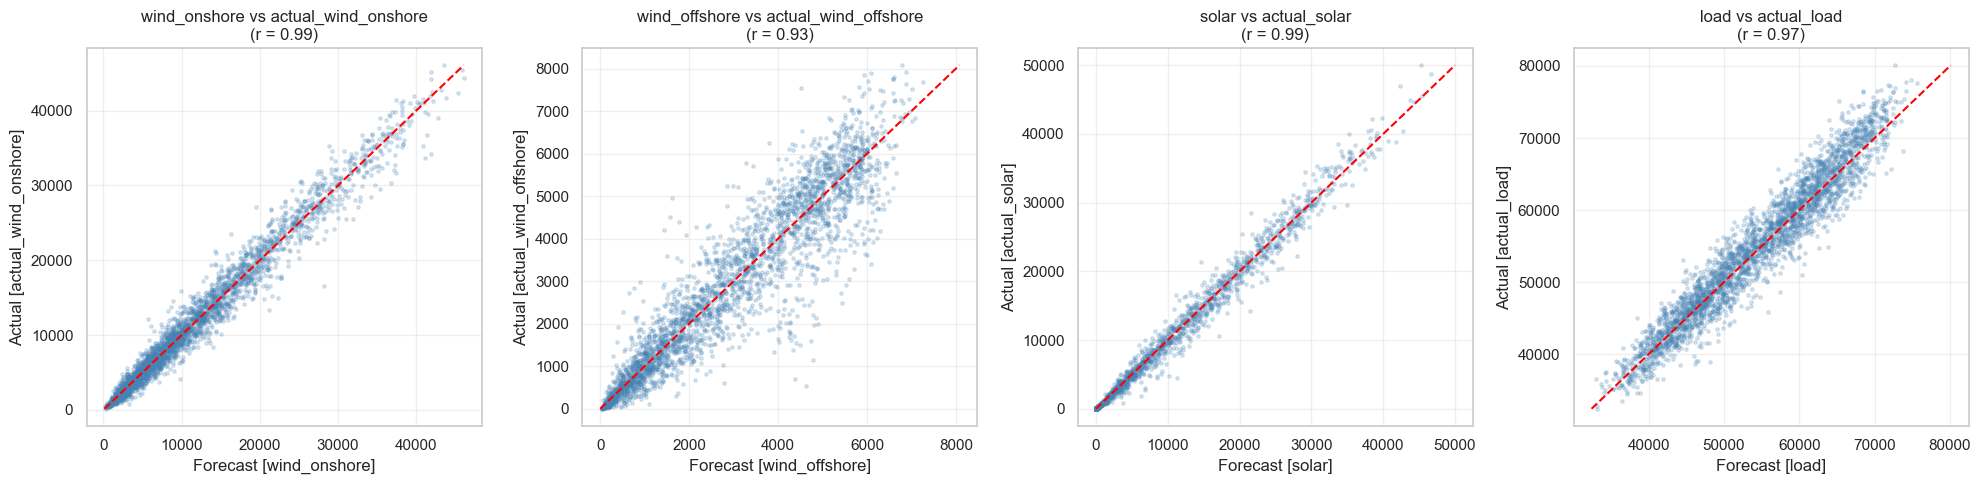

In [30]:
# Define forecast and actual column pairs
forecast_actual_pairs = [
    ("wind_onshore", "actual_wind_onshore"),
    ("wind_offshore", "actual_wind_offshore"),
    ("solar", "actual_solar"),
    ("load", "actual_load")
]

# Keep only pairs that exist in the dataframe
valid_pairs = [(f, a) for f, a in forecast_actual_pairs if f in df.columns and a in df.columns]

# Create one scatter plot per pair
fig, axes = plt.subplots(1, len(valid_pairs), figsize=(5 * len(valid_pairs), 5))
if len(valid_pairs) == 1:
    axes = [axes]

for ax, (forecast_col, actual_col) in zip(axes, valid_pairs):
    # Sample rows for faster plotting
    sample = df[[forecast_col, actual_col]].dropna().sample(
        min(3000, len(df[[forecast_col, actual_col]].dropna())),
        random_state=42
    )

    # Scatter plot of forecast vs actual values
    ax.scatter(sample[forecast_col], sample[actual_col], alpha=0.2, s=6, color="steelblue")

    # Add a 45-degree reference line for perfect forecasts
    min_val = min(sample[forecast_col].min(), sample[actual_col].min())
    max_val = max(sample[forecast_col].max(), sample[actual_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1.5)

    # Add labels and title
    corr_val = sample[forecast_col].corr(sample[actual_col])
    ax.set_title(f"{forecast_col} vs {actual_col}\n(r = {corr_val:.2f})")
    ax.set_xlabel(f"Forecast [{forecast_col}]")
    ax.set_ylabel(f"Actual [{actual_col}]")

plt.tight_layout()
plt.show()

### Multicollinearity: highly correlated pairs

In [31]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Compute the full numeric correlation matrix
corr_matrix_full = df[numeric_cols].corr()

# Keep only the upper triangle so pairs are not repeated
upper_triangle = corr_matrix_full.where(
    np.triu(np.ones(corr_matrix_full.shape), k=1).astype(bool)
)

# Extract highly correlated pairs above a chosen threshold
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"].abs() > 0.85]
high_corr_pairs = high_corr_pairs.sort_values("correlation", key=lambda x: x.abs(), ascending=False)

display(high_corr_pairs)

,feature_1,feature_2,correlation
137,solar,actual_solar,0.995181
109,wind_onshore,actual_wind_onshore,0.986638
54,load,actual_load,0.964511
80,wind_offshore,actual_wind_offshore,0.936066
269,gas_price,price_rolling_168h,0.932568
343,price_rolling_24h,price_rolling_168h,0.918154
446,nuclear_generation,year,-0.918049
265,gas_price,coal_price,0.908942
13,price,price_rolling_24h,0.902185
256,wind_speed,actual_wind_onshore,0.899127


This table highlights feature pairs with very strong linear correlation. Such pairs may contain redundant information and can indicate multicollinearity, which is particularly relevant for linear models and feature selection.

### Variance inflation factor (VIF)

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric columns and drop rows with missing values
vif_df = df.select_dtypes(include=np.number).dropna().copy()

# Optional: remove the target variable from VIF calculation
if "price" in vif_df.columns:
    vif_df = vif_df.drop(columns=["price"])

# Take a sample if the dataframe is very large
vif_sample = vif_df.sample(min(5000, len(vif_df)), random_state=42)

# Compute VIF for each feature
vif_results = pd.DataFrame({
    "feature": vif_sample.columns,
    "VIF": [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_results)

c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,load,inf
1,wind_offshore,inf
29,err_solar,inf
28,err_wind_onshore,inf
27,err_wind_offshore,inf
25,residual_demand,inf
24,actual_load,inf
23,actual_solar,inf
22,actual_wind_onshore,inf
21,actual_wind_offshore,inf


The VIF values quantify how strongly each feature is linearly explained by the other features. High VIF values indicate stronger multicollinearity and suggest that some variables may be redundant in a regression-based modelling setup.

In [33]:
print(df["net_export"].dtype)
print(df["net_export"].head())
print(df["net_export"].isna().sum())

float64
0    13001.0
1    13461.0
2    13093.0
3    13258.0
4    13182.0
Name: net_export, dtype: float64
0


### Power-system balance before and after 2023

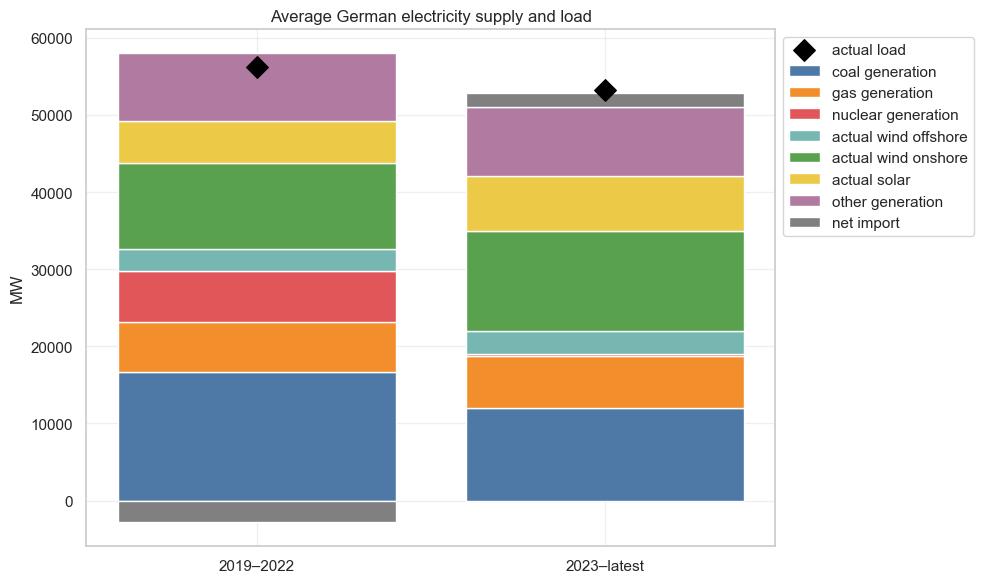

In [34]:
# Create a clean copy from the original dataframe
df_balance = df.copy()

# Define additional derived columns
df_balance["other_generation"] = (
    df_balance["total_generation"]
    - df_balance["coal_generation"]
    - df_balance["gas_generation"]
    - df_balance["nuclear_generation"]
    - df_balance["actual_wind_offshore"]
    - df_balance["actual_wind_onshore"]
    - df_balance["actual_solar"]
)

# Convert net export to net import representation
df_balance["net_import"] = -df_balance["net_export"]

# Split into two time periods
period_1 = df_balance[df_balance["timestamp"].dt.year <= 2022]
period_2 = df_balance[df_balance["timestamp"].dt.year >= 2023]

# Compute average values for both periods
avg_1 = period_1.mean(numeric_only=True)
avg_2 = period_2.mean(numeric_only=True)

# Define generation categories
gen_cols = [
    "coal_generation",
    "gas_generation",
    "nuclear_generation",
    "actual_wind_offshore",
    "actual_wind_onshore",
    "actual_solar",
    "other_generation"
]

colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1"]

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
x = [0, 1]
bottom_1 = 0
bottom_2 = 0

for col, color in zip(gen_cols, colors):
    ax.bar(x[0], avg_1[col], bottom=bottom_1, color=color, label=col.replace("_", " "))
    ax.bar(x[1], avg_2[col], bottom=bottom_2, color=color)
    bottom_1 += avg_1[col]
    bottom_2 += avg_2[col]

# Add net imports
ax.bar(
    x[0],
    avg_1["net_import"],
    bottom=bottom_1 if avg_1["net_import"] >= 0 else 0,
    color="grey",
    label="net import"
)
ax.bar(
    x[1],
    avg_2["net_import"],
    bottom=bottom_2 if avg_2["net_import"] >= 0 else 0,
    color="grey"
)

# Add actual load markers
ax.scatter(x[0], avg_1["actual_load"], marker="D", s=120, color="black", label="actual load", zorder=5)
ax.scatter(x[1], avg_2["actual_load"], marker="D", s=120, color="black", zorder=5)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(["2019–2022", "2023–latest"])
ax.set_ylabel("MW")
ax.set_title("Average German electricity supply and load")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Train, validation, and test split sanity check

Train: 2019-01-08 00:00:00 → 2024-09-29 03:00:00 (50,182 rows)
Validation: 2024-09-29 04:00:00 → 2025-06-17 13:00:00 (6,273 rows)
Test: 2025-06-17 14:00:00 → 2026-03-05 22:00:00 (6,273 rows)


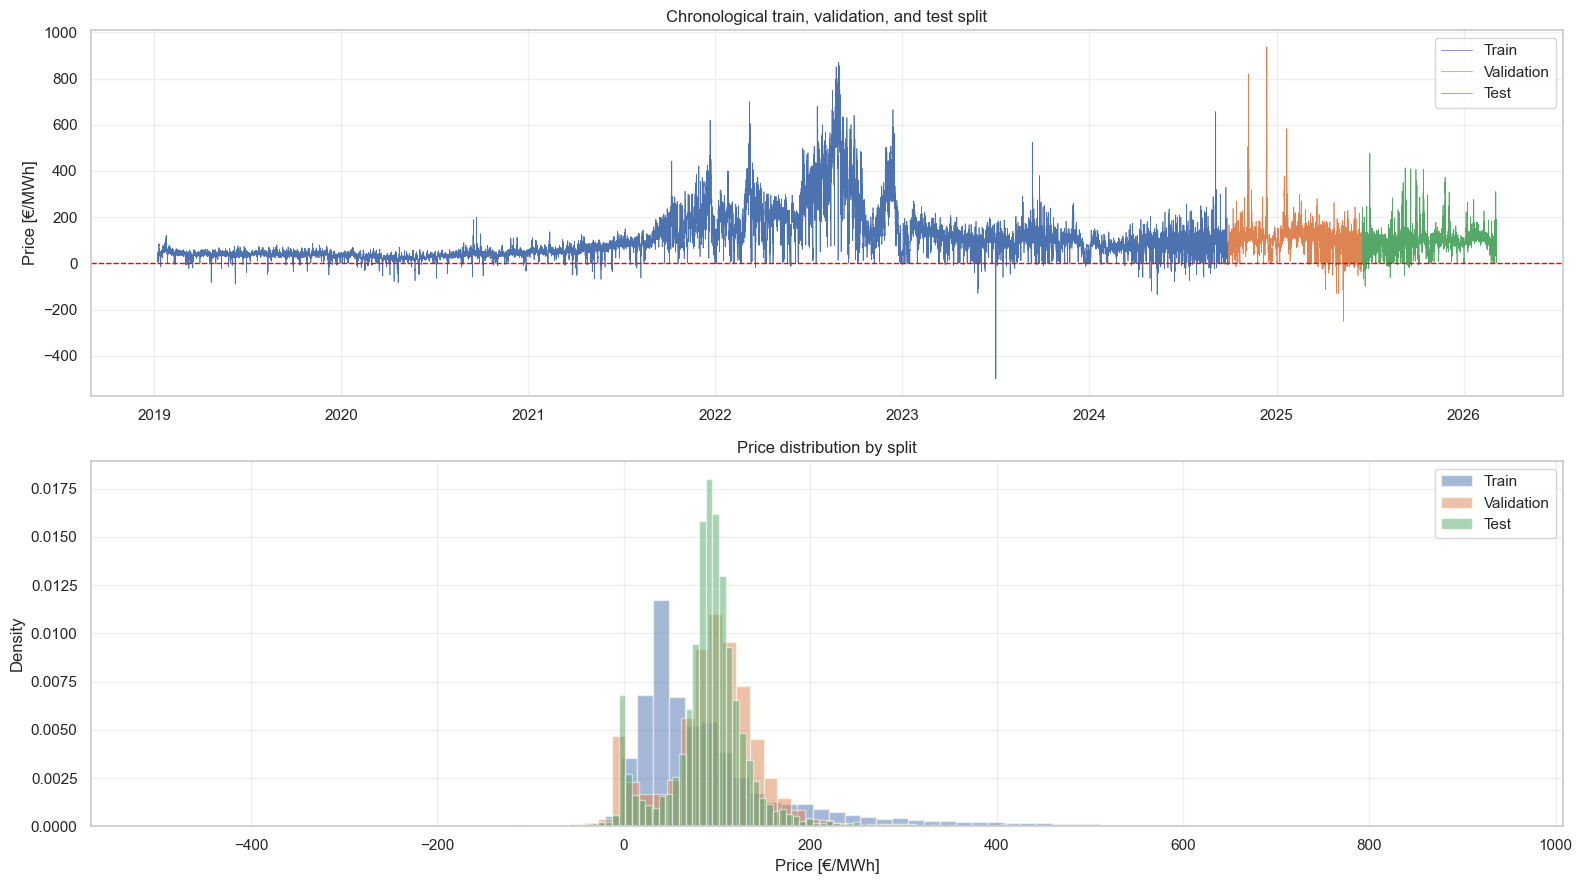

In [35]:
# Sort by time to preserve chronological order
df_split = df.sort_values("timestamp").reset_index(drop=True)

# Define split indices
n_rows = len(df_split)
train_end = int(n_rows * 0.80)
val_end = int(n_rows * 0.90)

# Create chronological splits
df_train = df_split.iloc[:train_end]
df_val = df_split.iloc[train_end:val_end]
df_test = df_split.iloc[val_end:]

# Print the time range of each split
print("Train:", df_train["timestamp"].min(), "→", df_train["timestamp"].max(), f"({len(df_train):,} rows)")
print("Validation:", df_val["timestamp"].min(), "→", df_val["timestamp"].max(), f"({len(df_val):,} rows)")
print("Test:", df_test["timestamp"].min(), "→", df_test["timestamp"].max(), f"({len(df_test):,} rows)")

# Plot the target variable across the three splits
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

axes[0].plot(df_train["timestamp"], df_train["price"], linewidth=0.5, label="Train")
axes[0].plot(df_val["timestamp"], df_val["price"], linewidth=0.5, label="Validation")
axes[0].plot(df_test["timestamp"], df_test["price"], linewidth=0.5, label="Test")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Chronological train, validation, and test split")
axes[0].set_ylabel("Price [€/MWh]")
axes[0].legend()

# Compare the price distributions in the three splits
axes[1].hist(df_train["price"], bins=80, alpha=0.5, density=True, label="Train")
axes[1].hist(df_val["price"], bins=80, alpha=0.5, density=True, label="Validation")
axes[1].hist(df_test["price"], bins=80, alpha=0.5, density=True, label="Test")
axes[1].set_title("Price distribution by split")
axes[1].set_xlabel("Price [€/MWh]")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

This section checks whether the chronological train, validation, and test splits cover different market periods and whether their price distributions are similar or noticeably different. Large differences may indicate regime shifts and can affect model evaluation.

### Leakage / model-readiness check: Feature availability and model-readiness check

In [36]:
# List all candidate features except timestamp and target
feature_cols = [col for col in df.columns if col not in ["timestamp", "price"]]

# Classify features by likely availability for a 24-hour-ahead forecast
readiness_rows = []

for col in feature_cols:
    if any(tag in col for tag in ["lag_24", "lag_168", "rolling_168"]):
        status = "Safe"
        note = "Uses information from at least one day earlier."
    elif any(tag in col for tag in ["lag_1", "lag_2", "lag_3", "lag_6", "lag_12"]):
        status = "Potential leakage"
        note = "Uses too recent information for a 24-hour-ahead forecast."
    elif "rolling_24" in col:
        status = "Check carefully"
        note = "Safe only if the rolling window is shifted appropriately."
    elif "actual_" in col:
        status = "Check carefully"
        note = "May not be available at forecast time."
    elif col in ["hour", "day_of_week", "month", "year", "is_weekend", "is_holiday", "is_hol_or_week"]:
        status = "Safe"
        note = "Calendar information is known in advance."
    else:
        status = "Likely safe"
        note = "Needs confirmation based on data source and forecast setup."

    readiness_rows.append({"feature": col, "status": status, "note": note})

readiness_df = pd.DataFrame(readiness_rows)
display(readiness_df.sort_values(["status", "feature"]))

,feature,status,note
27,actual_load,Check carefully,May not be available at forecast time.
26,actual_solar,Check carefully,May not be available at forecast time.
24,actual_wind_offshore,Check carefully,May not be available at forecast time.
25,actual_wind_onshore,Check carefully,May not be available at forecast time.
14,price_rolling_24h,Check carefully,Safe only if the rolling window is shifted app...
16,co2_price,Likely safe,Needs confirmation based on data source and fo...
21,coal_generation,Likely safe,Needs confirmation based on data source and fo...
11,coal_price,Likely safe,Needs confirmation based on data source and fo...
28,day_type,Likely safe,Needs confirmation based on data source and fo...
36,err_load,Likely safe,Needs confirmation based on data source and fo...


This table gives a first modelling-oriented check of whether the engineered features are likely to be available at prediction time for a 24-hour-ahead forecast. It helps identify potential leakage risks and features that may require additional verification.